In [4]:
import os
from utils.MOO_utilities import *

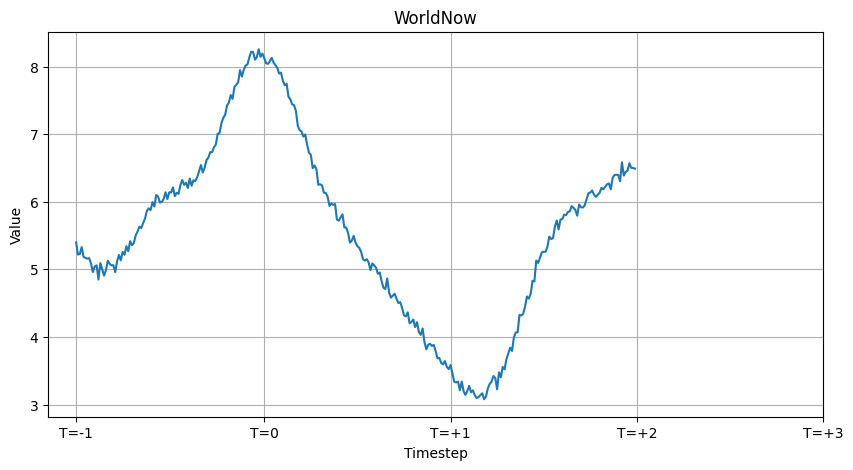

In [5]:
dr = DataReader("./data/Bundle3")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

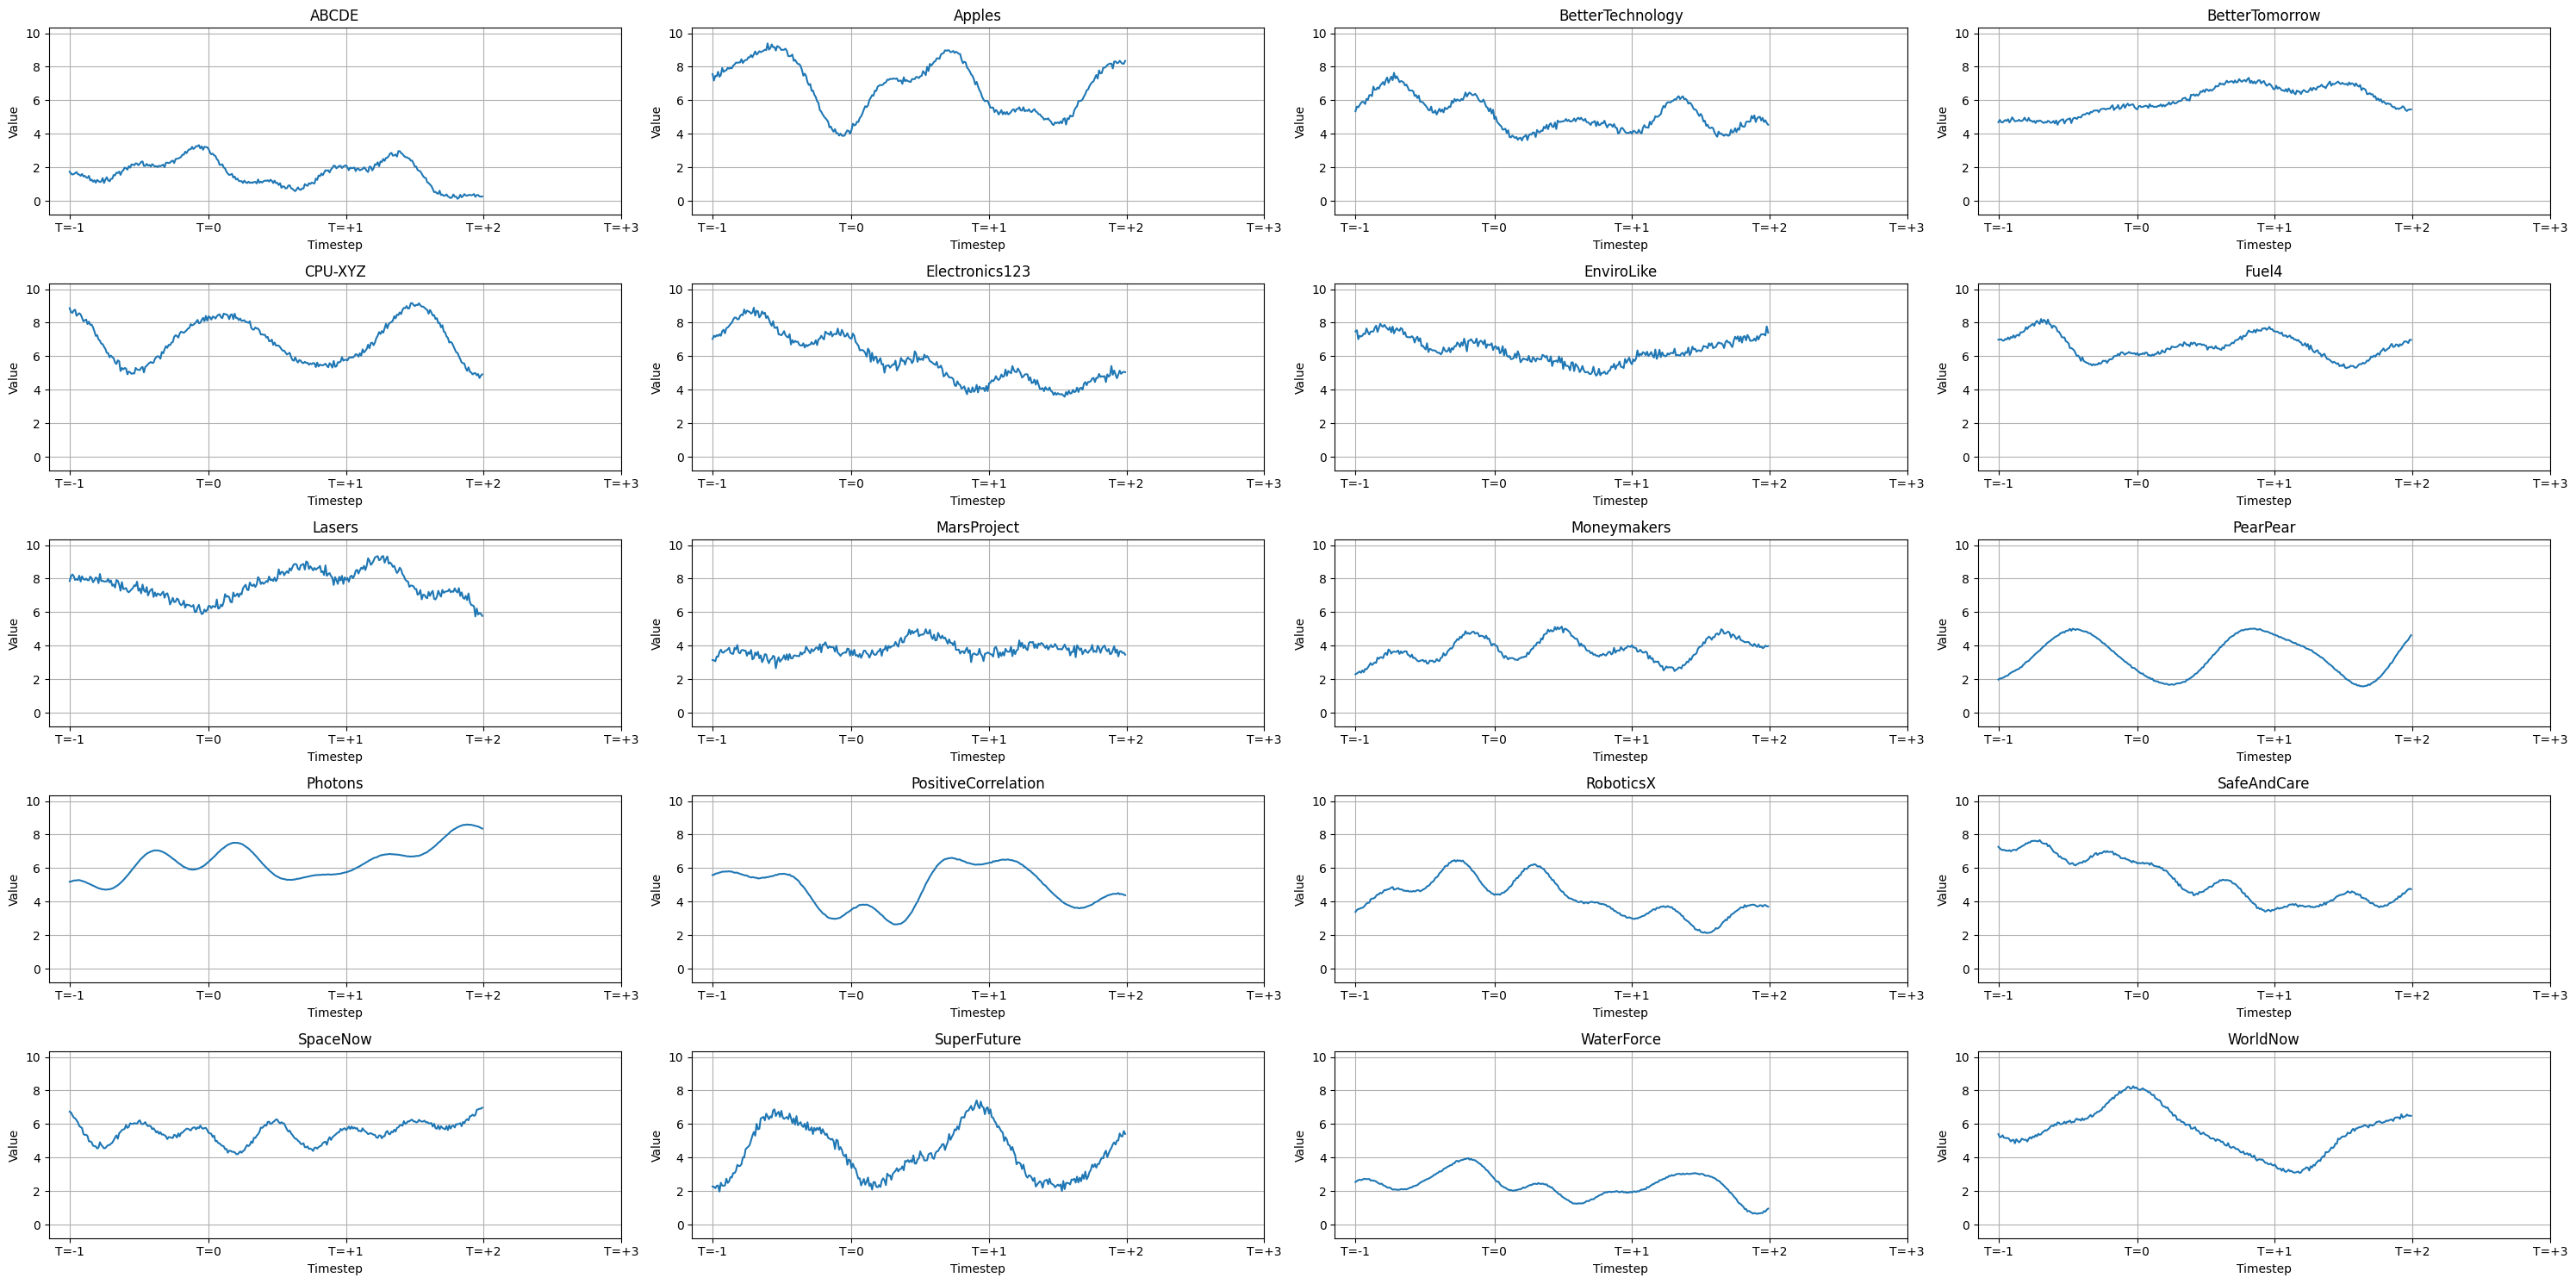

In [6]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

In [7]:
# Load all predictions and ground truth data
regression_models = ["Linear", "Sinusoidal", "Complex Sinusoidal", "ARIMA", "XGBoost", "NODE"]
base_dir = "./data/Predictions3"

loaded_data = {}
for model in regression_models:
    model_dir = os.path.join(base_dir, model)
    loaded_data[model] = {}

    for company in ORDER:
        company_dir = os.path.join(model_dir, company)
        indexes = np.load(os.path.join(company_dir, "indexes.npy"))
        predictions = np.load(os.path.join(company_dir, "predictions.npy"))
        loaded_data[model][company] = (indexes, predictions)

In [8]:
regression_predictions = []
for model in regression_models:
    regression_predictions.append(loaded_data[model])

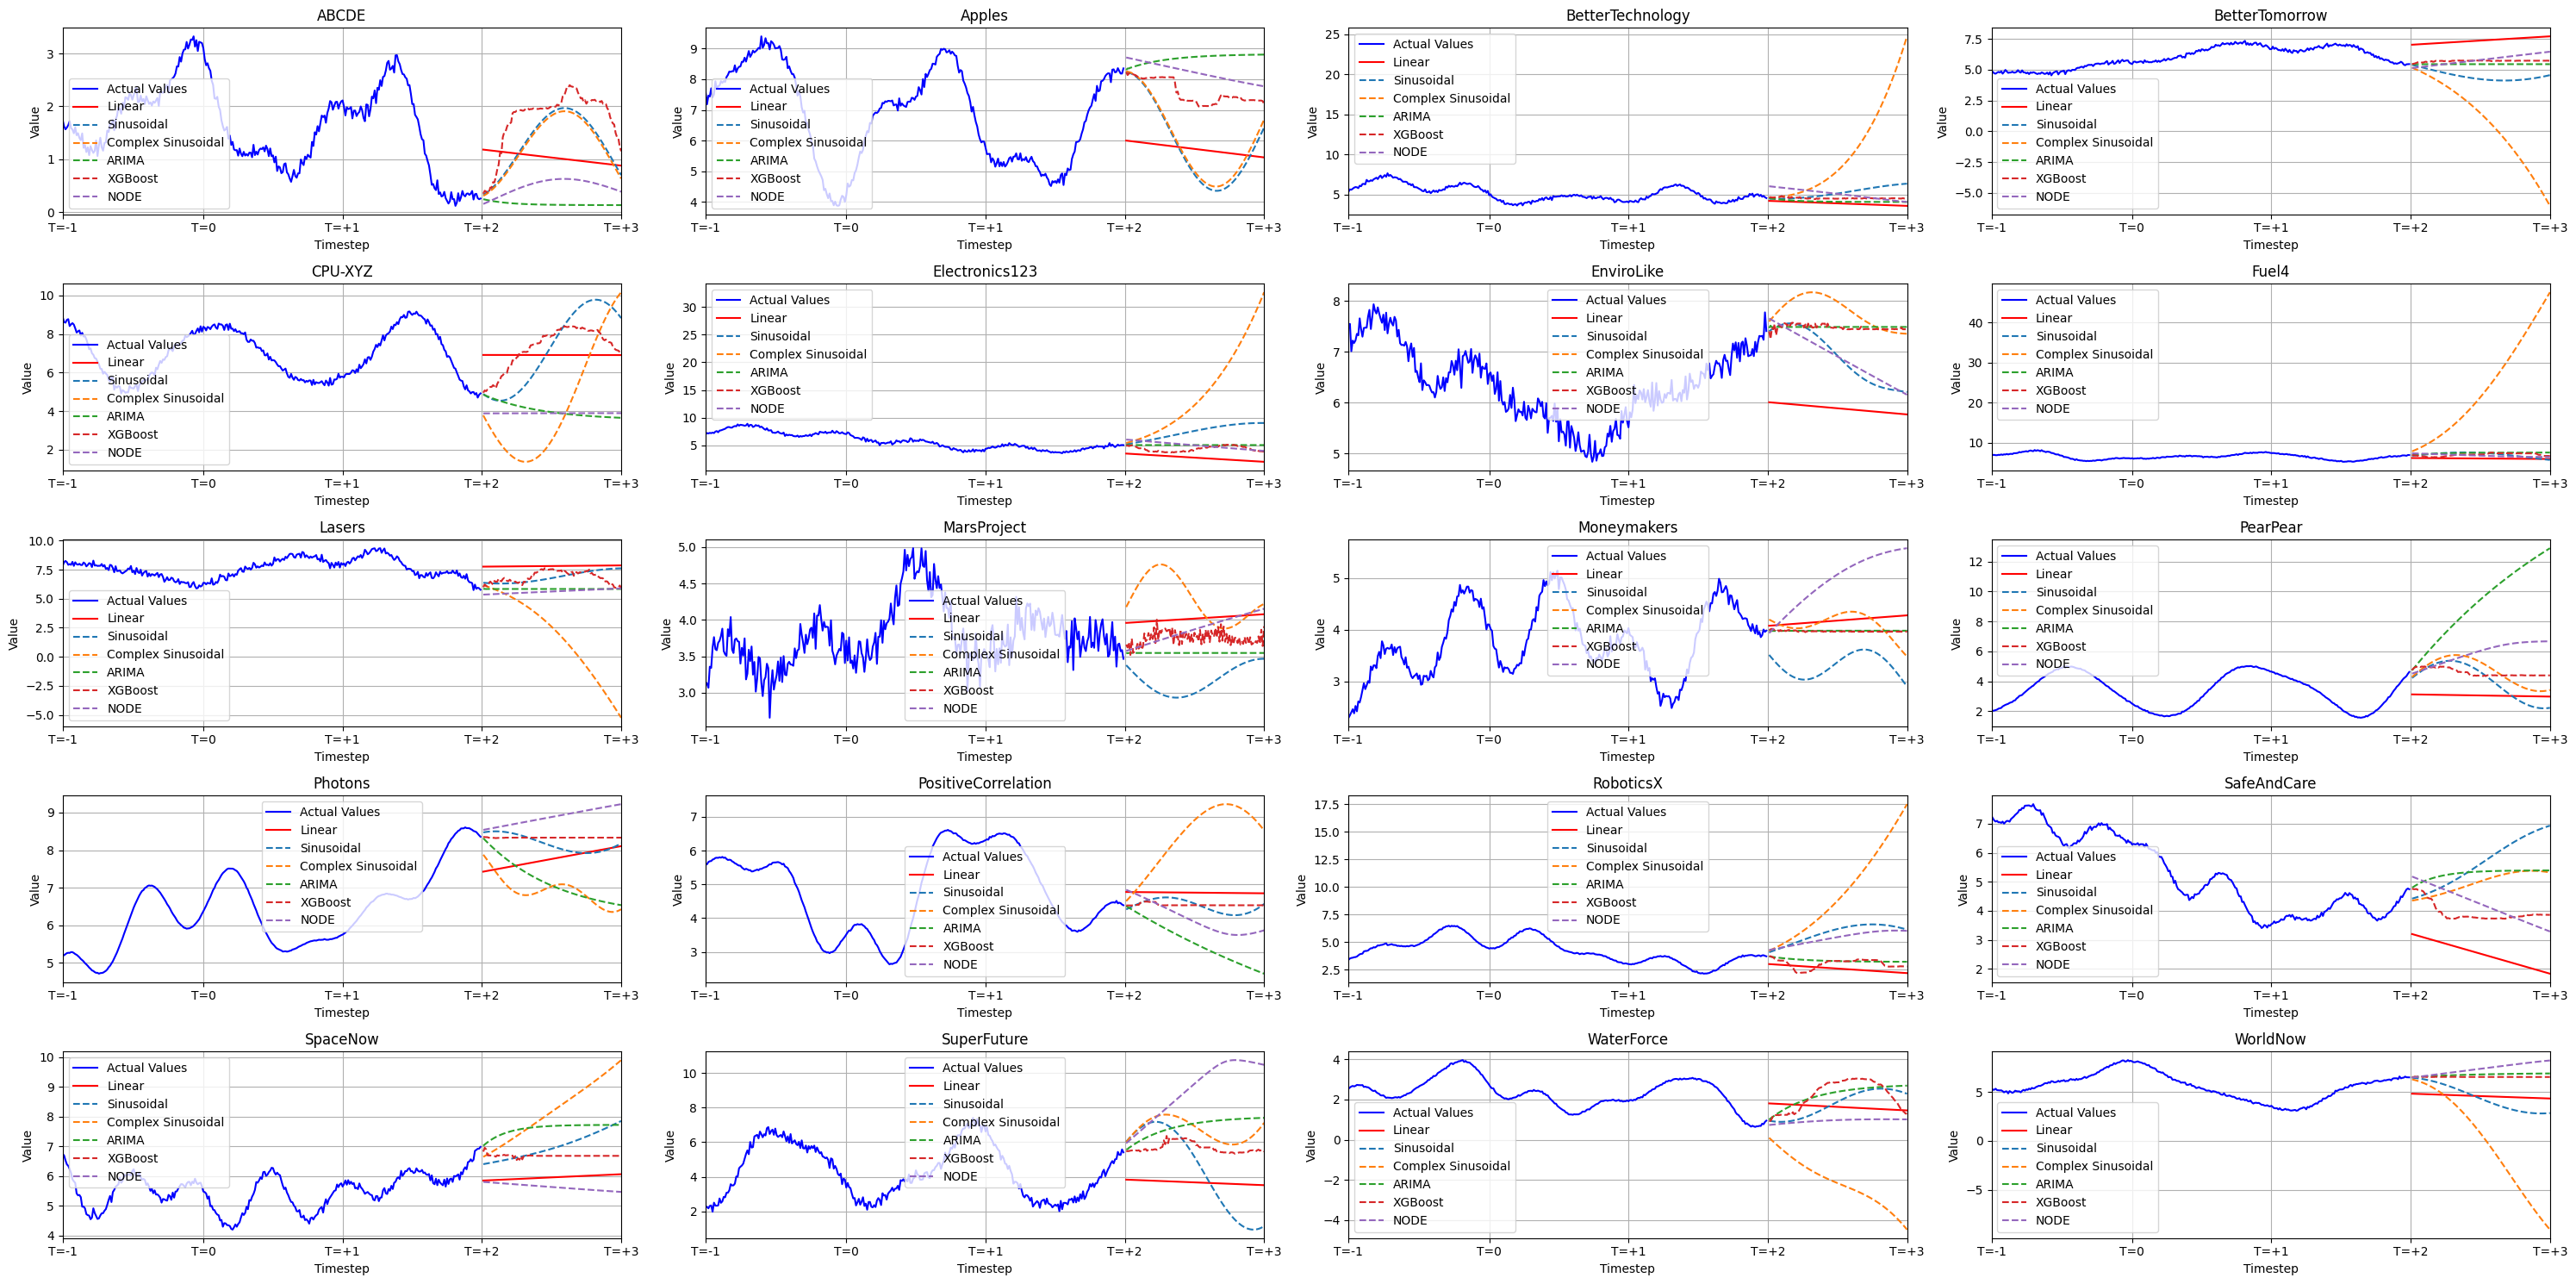

In [9]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.plot_multiple_predictions(val_range=401, predictions_list=regression_predictions, 
                              figsize=(30, 15), titles=regression_models)


Linear


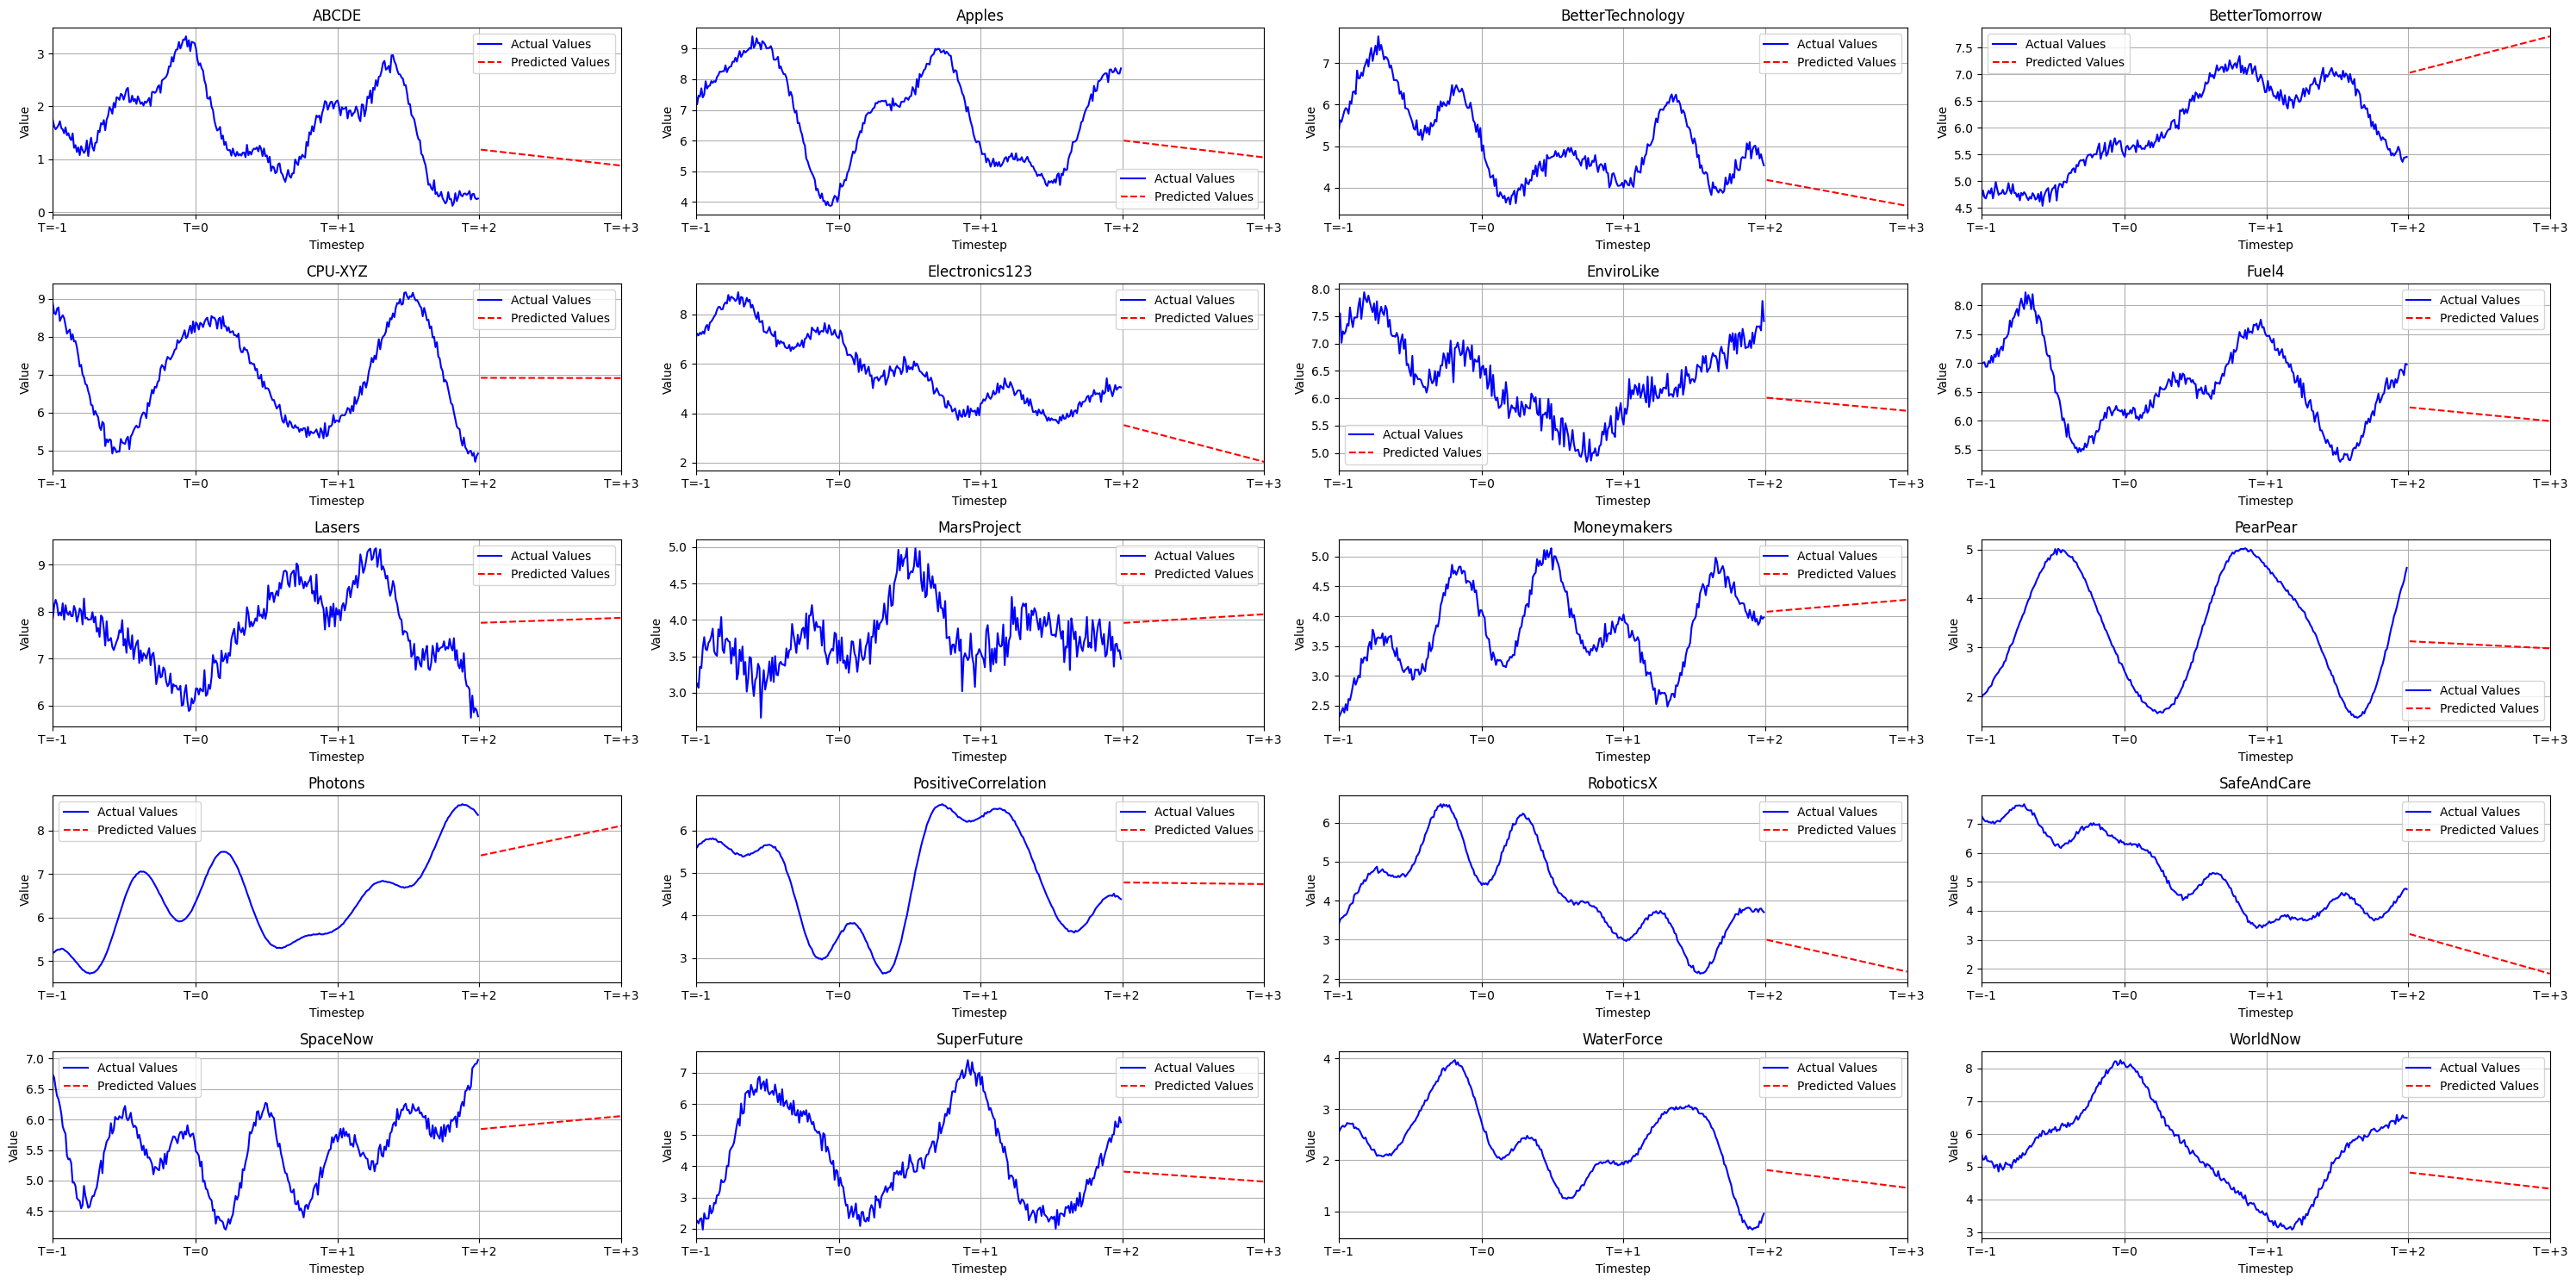

Sinusoidal


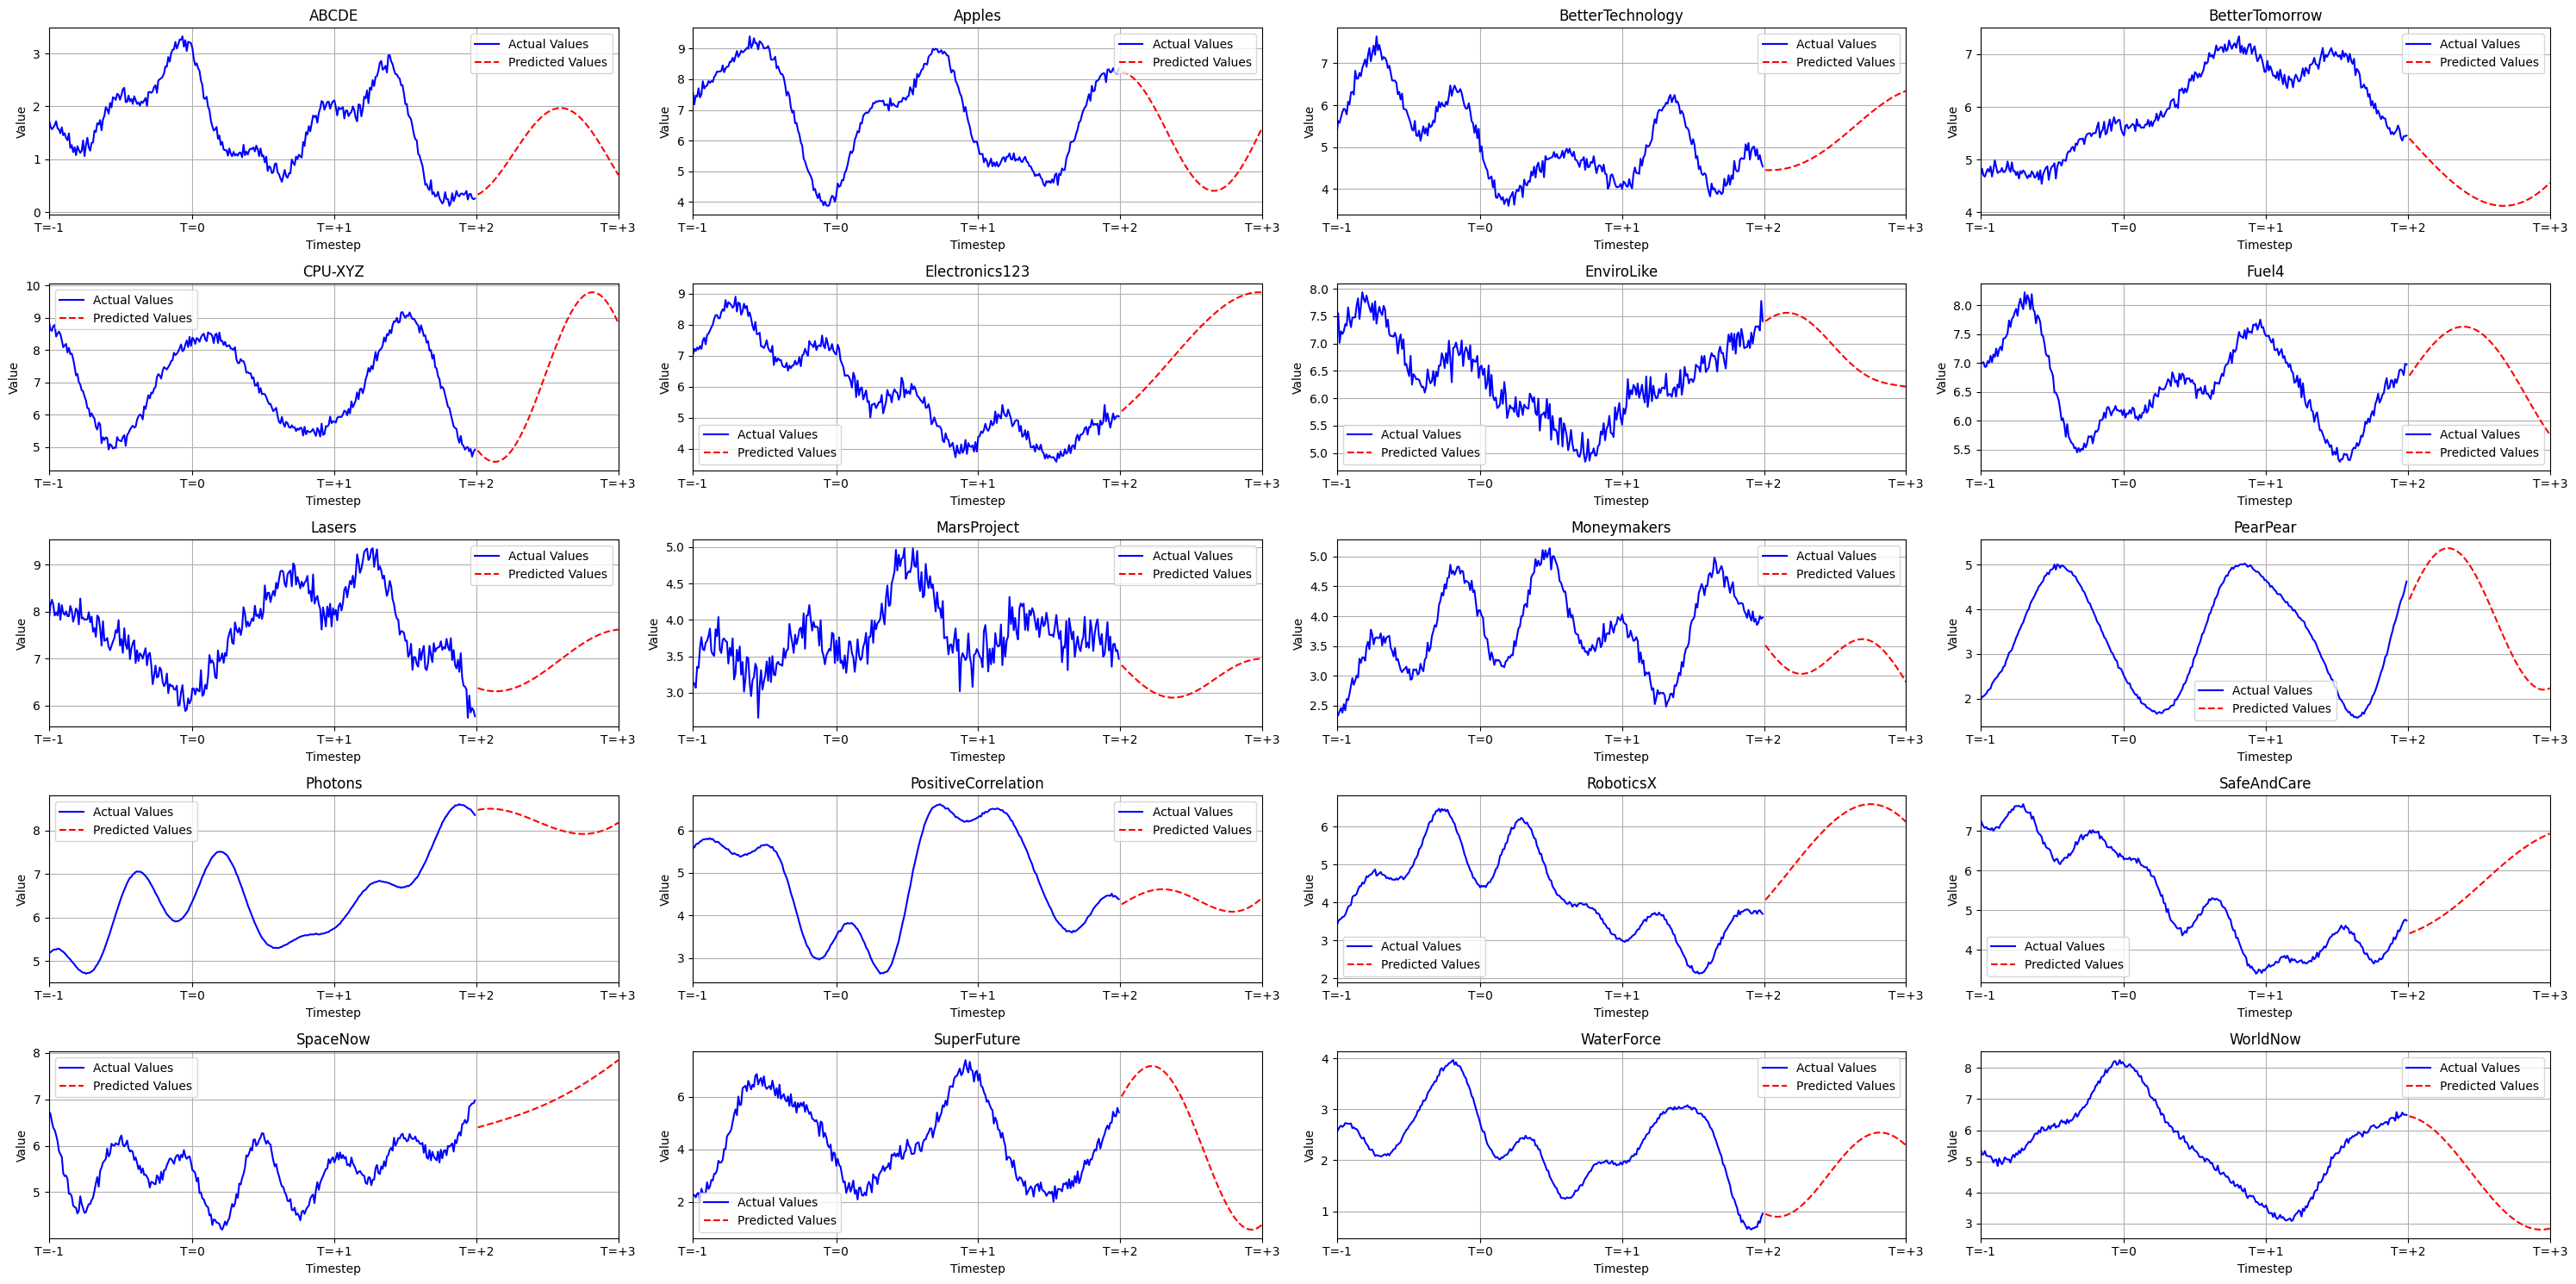

Complex Sinusoidal


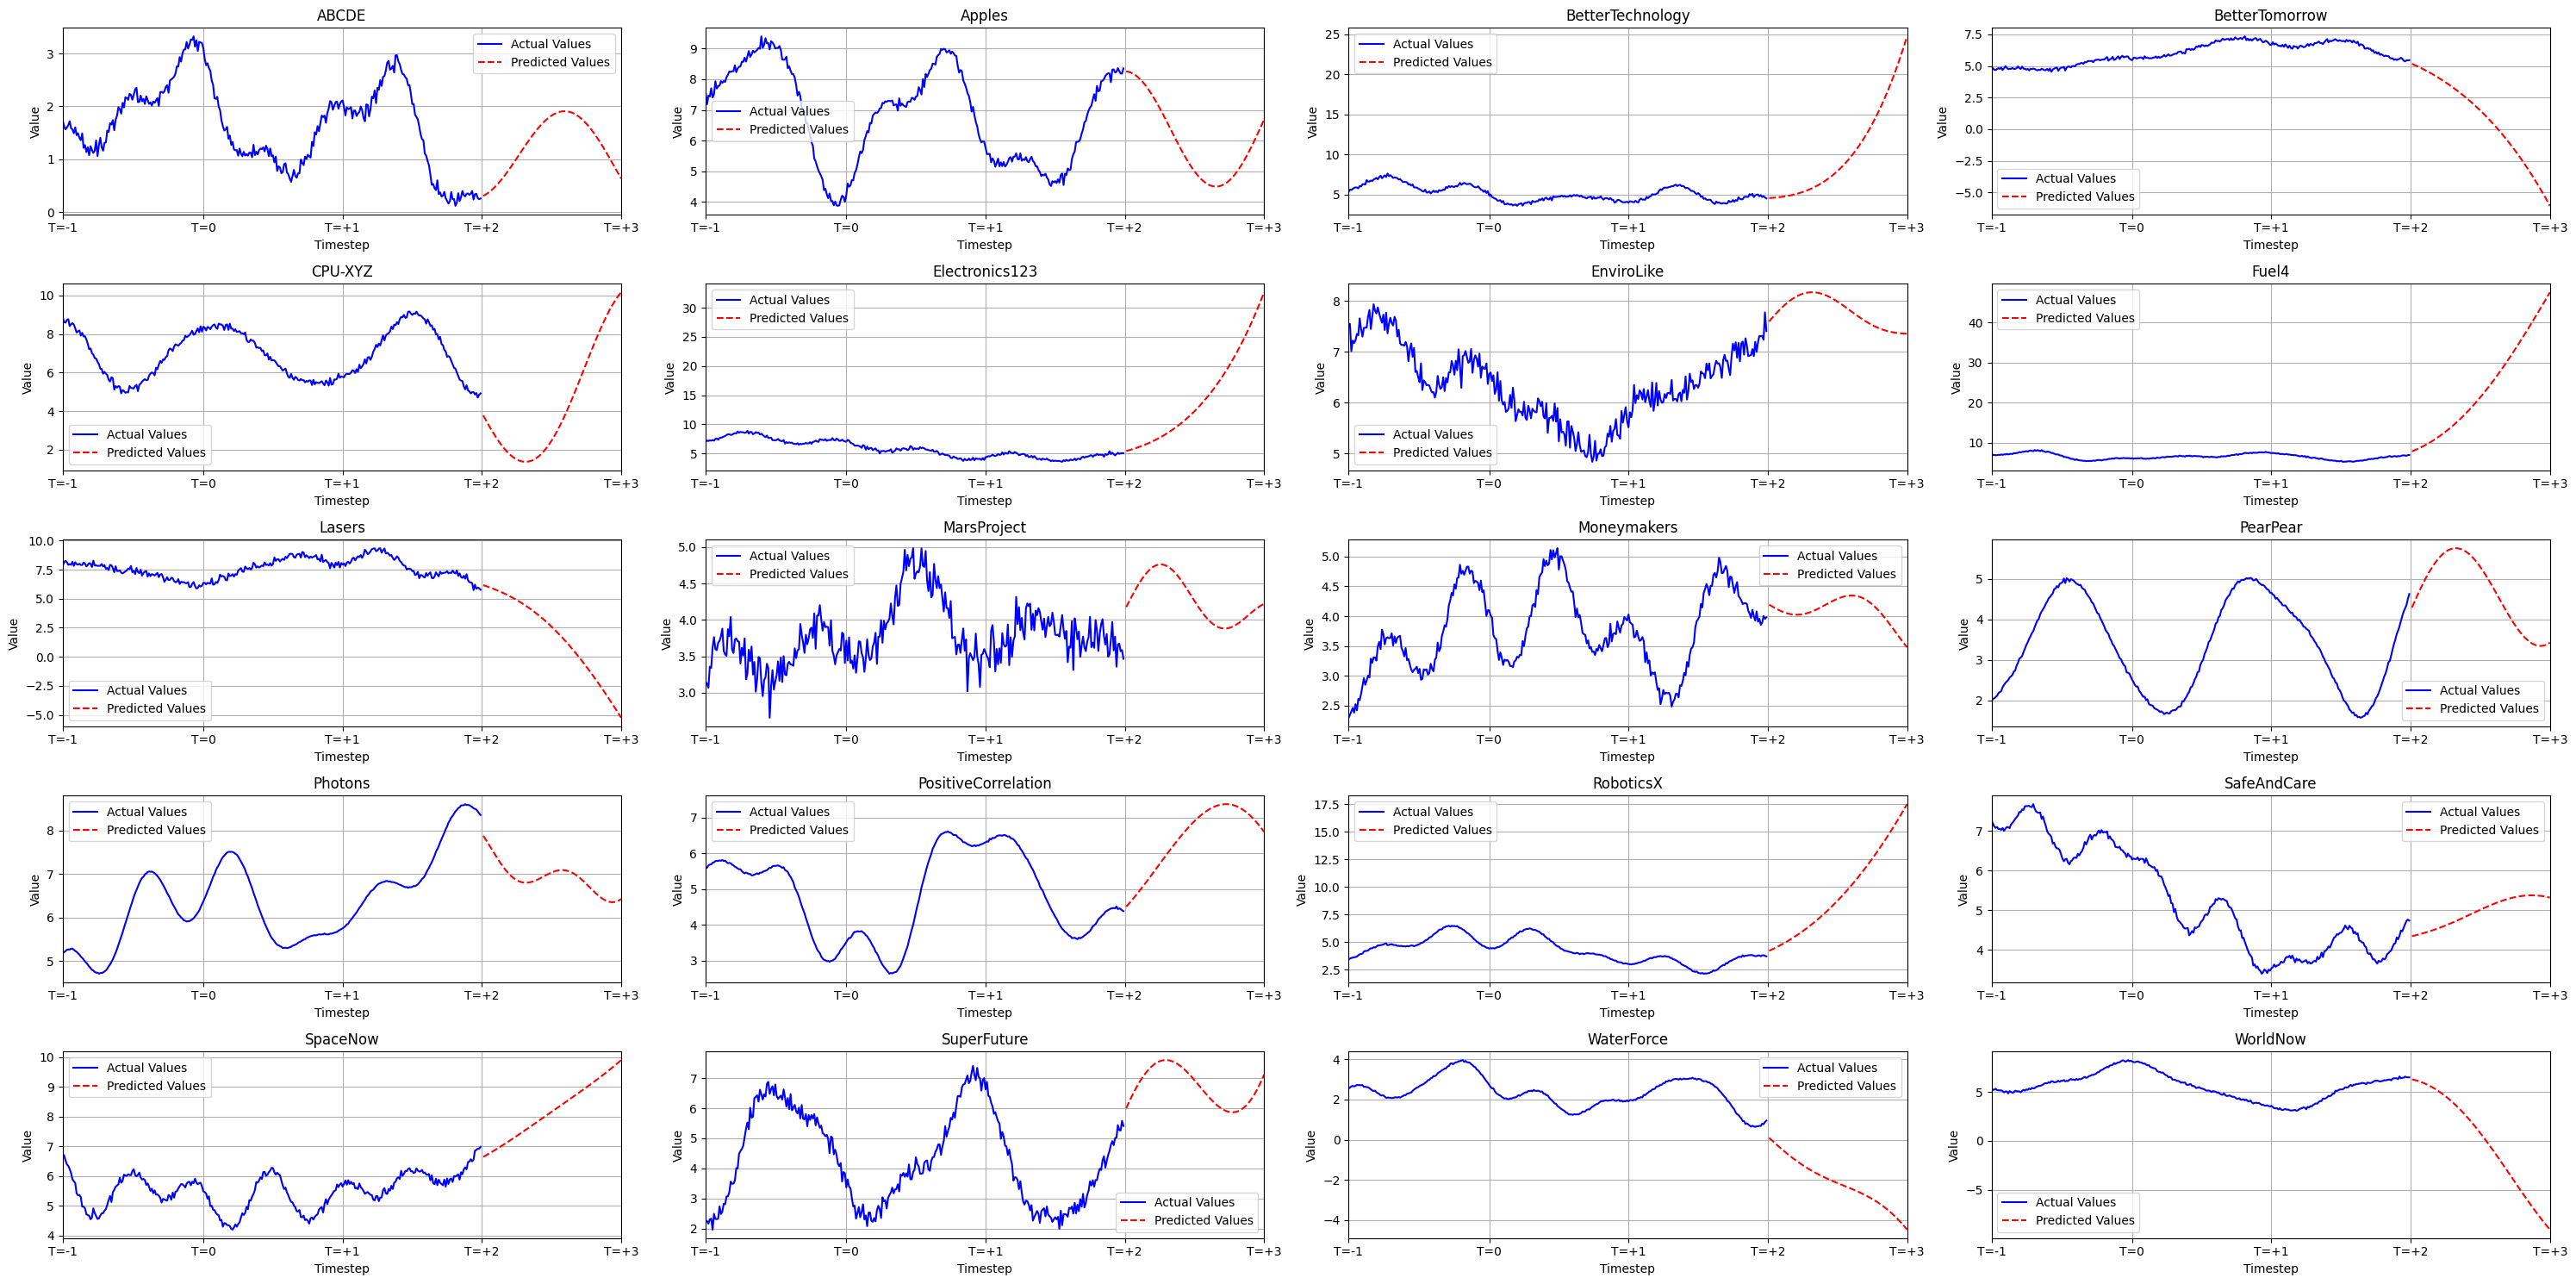

ARIMA


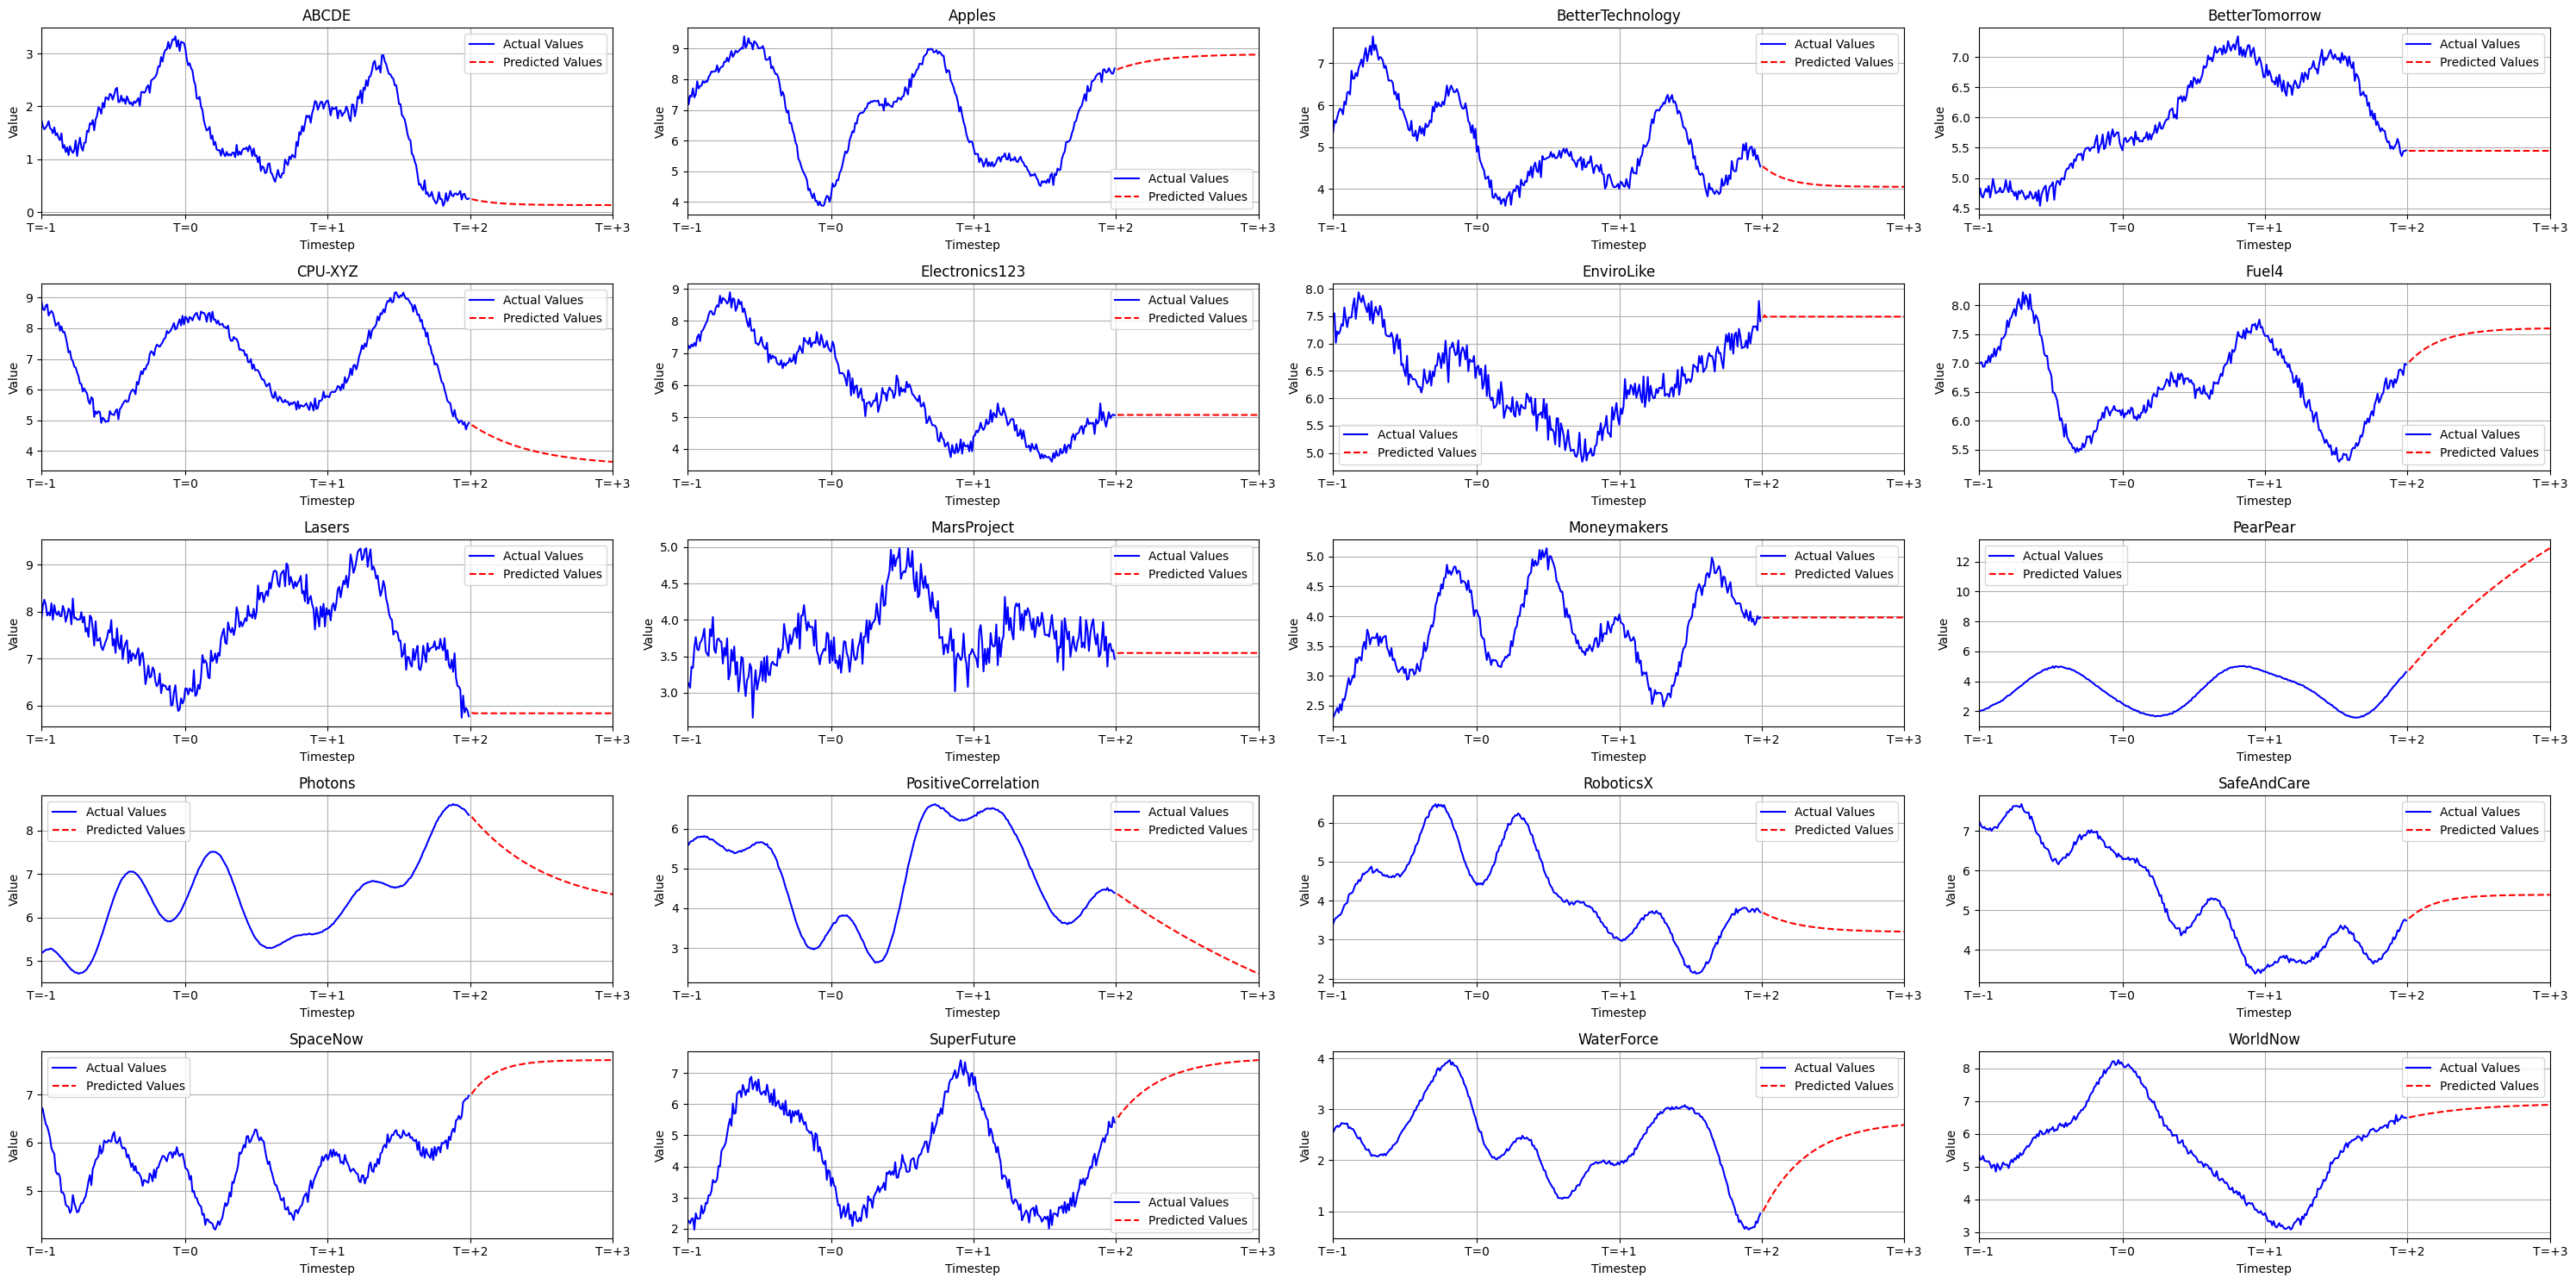

XGBoost


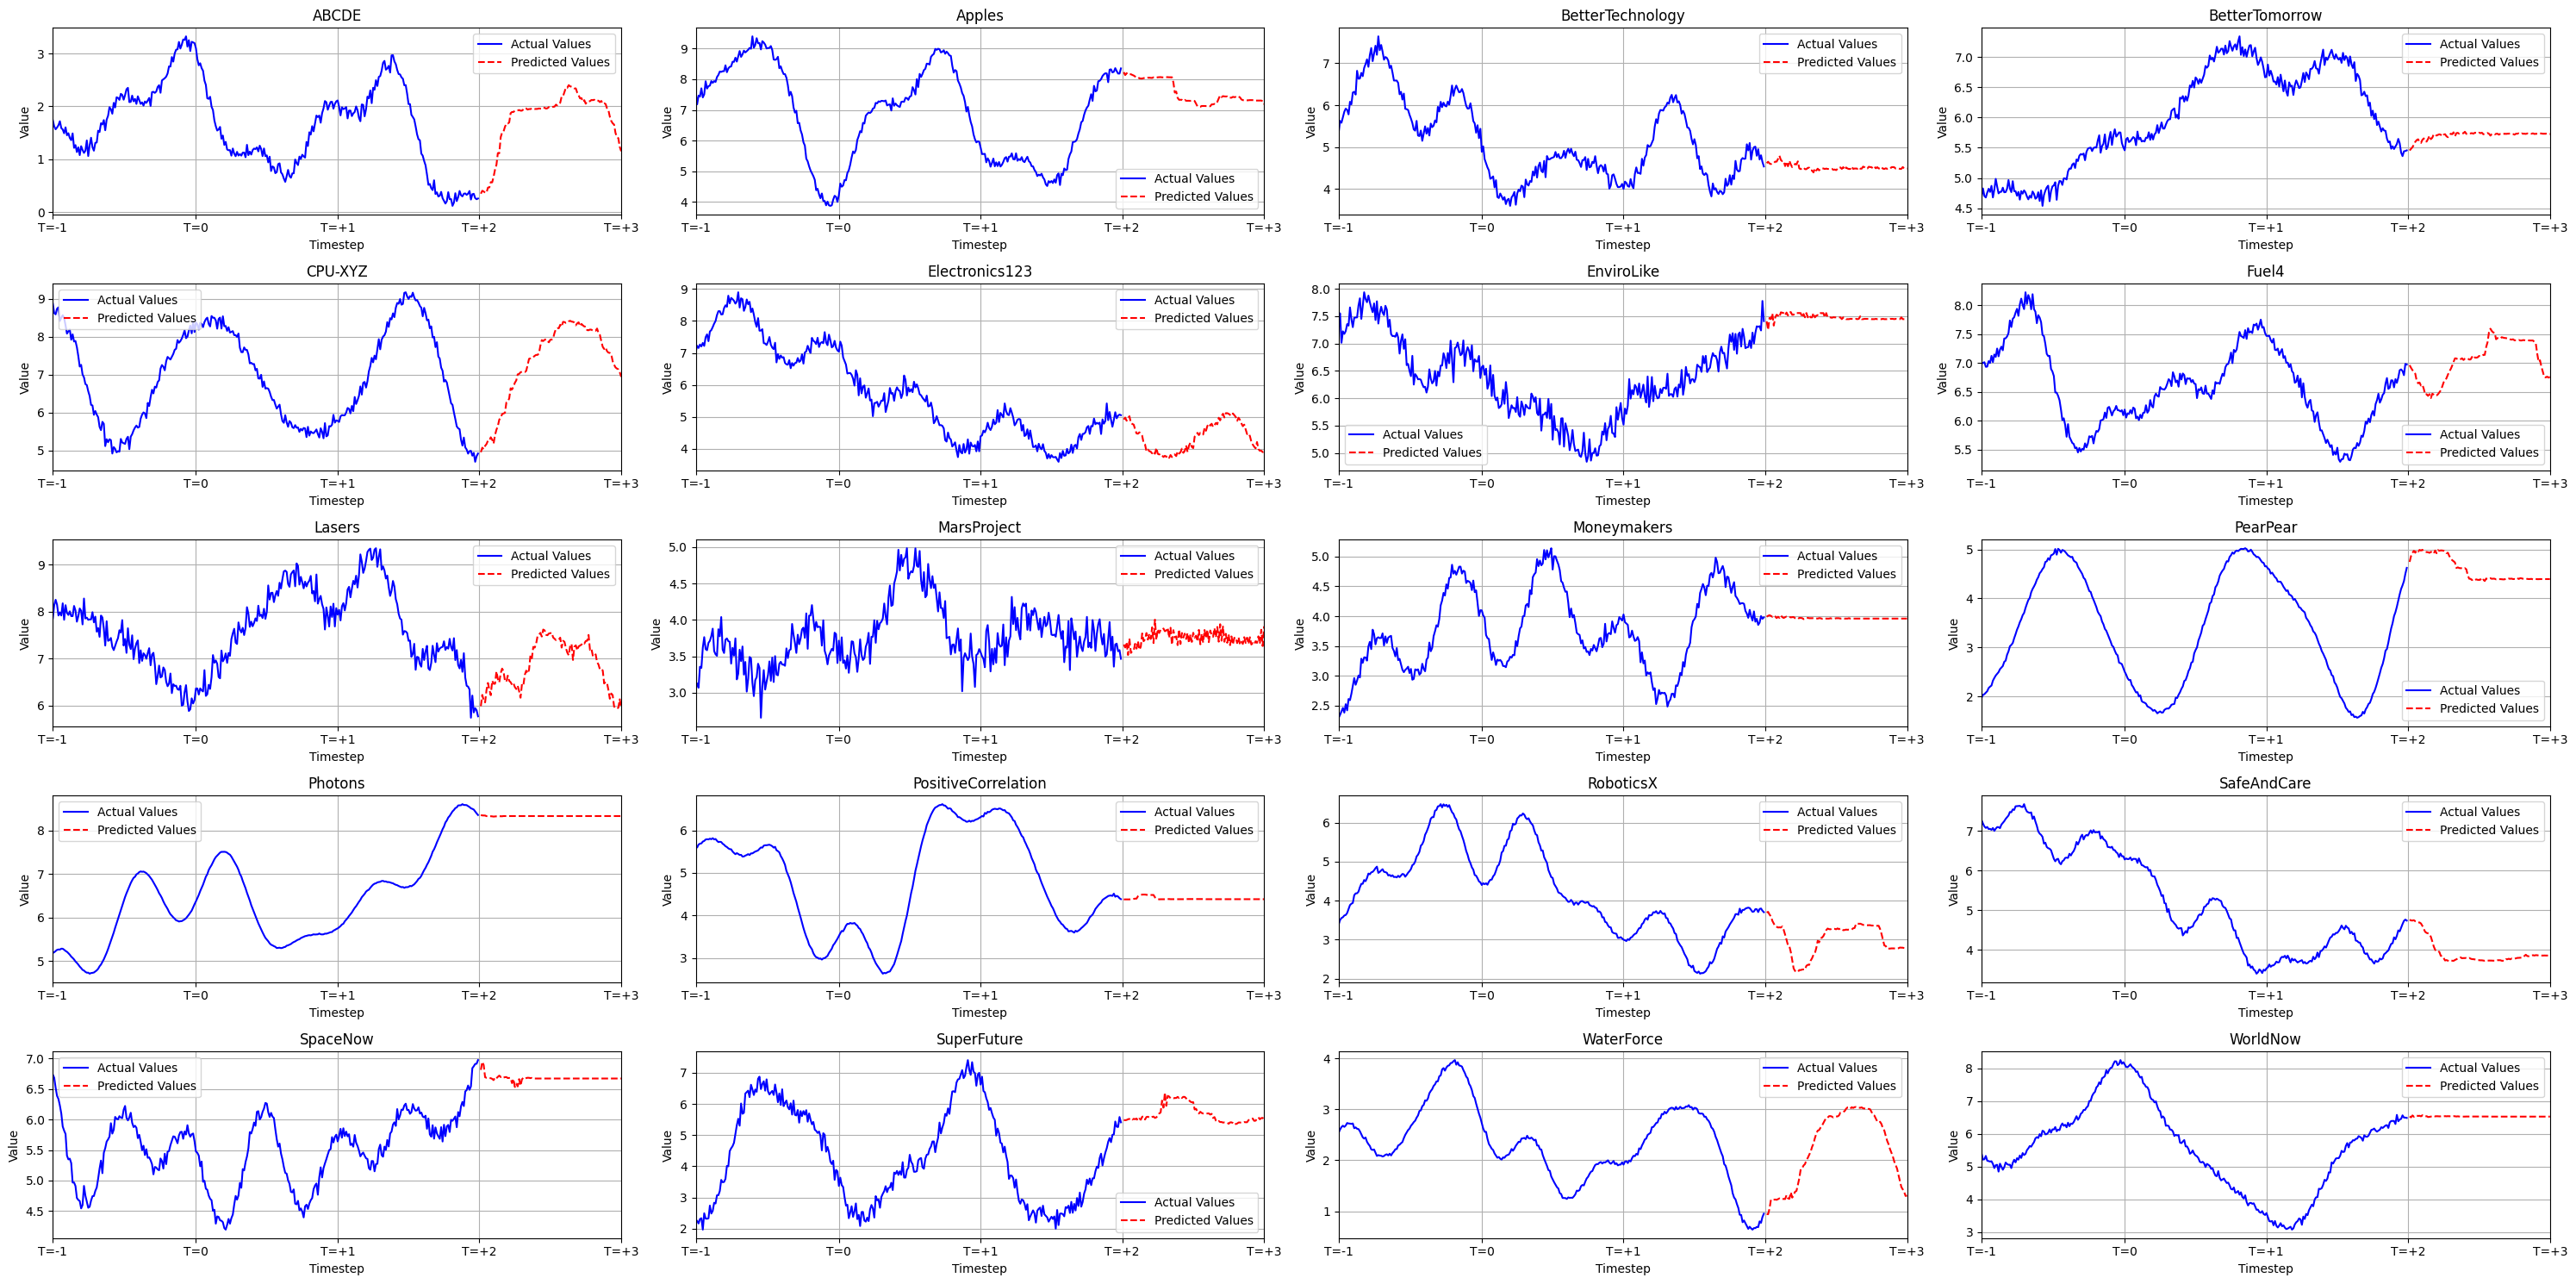

NODE


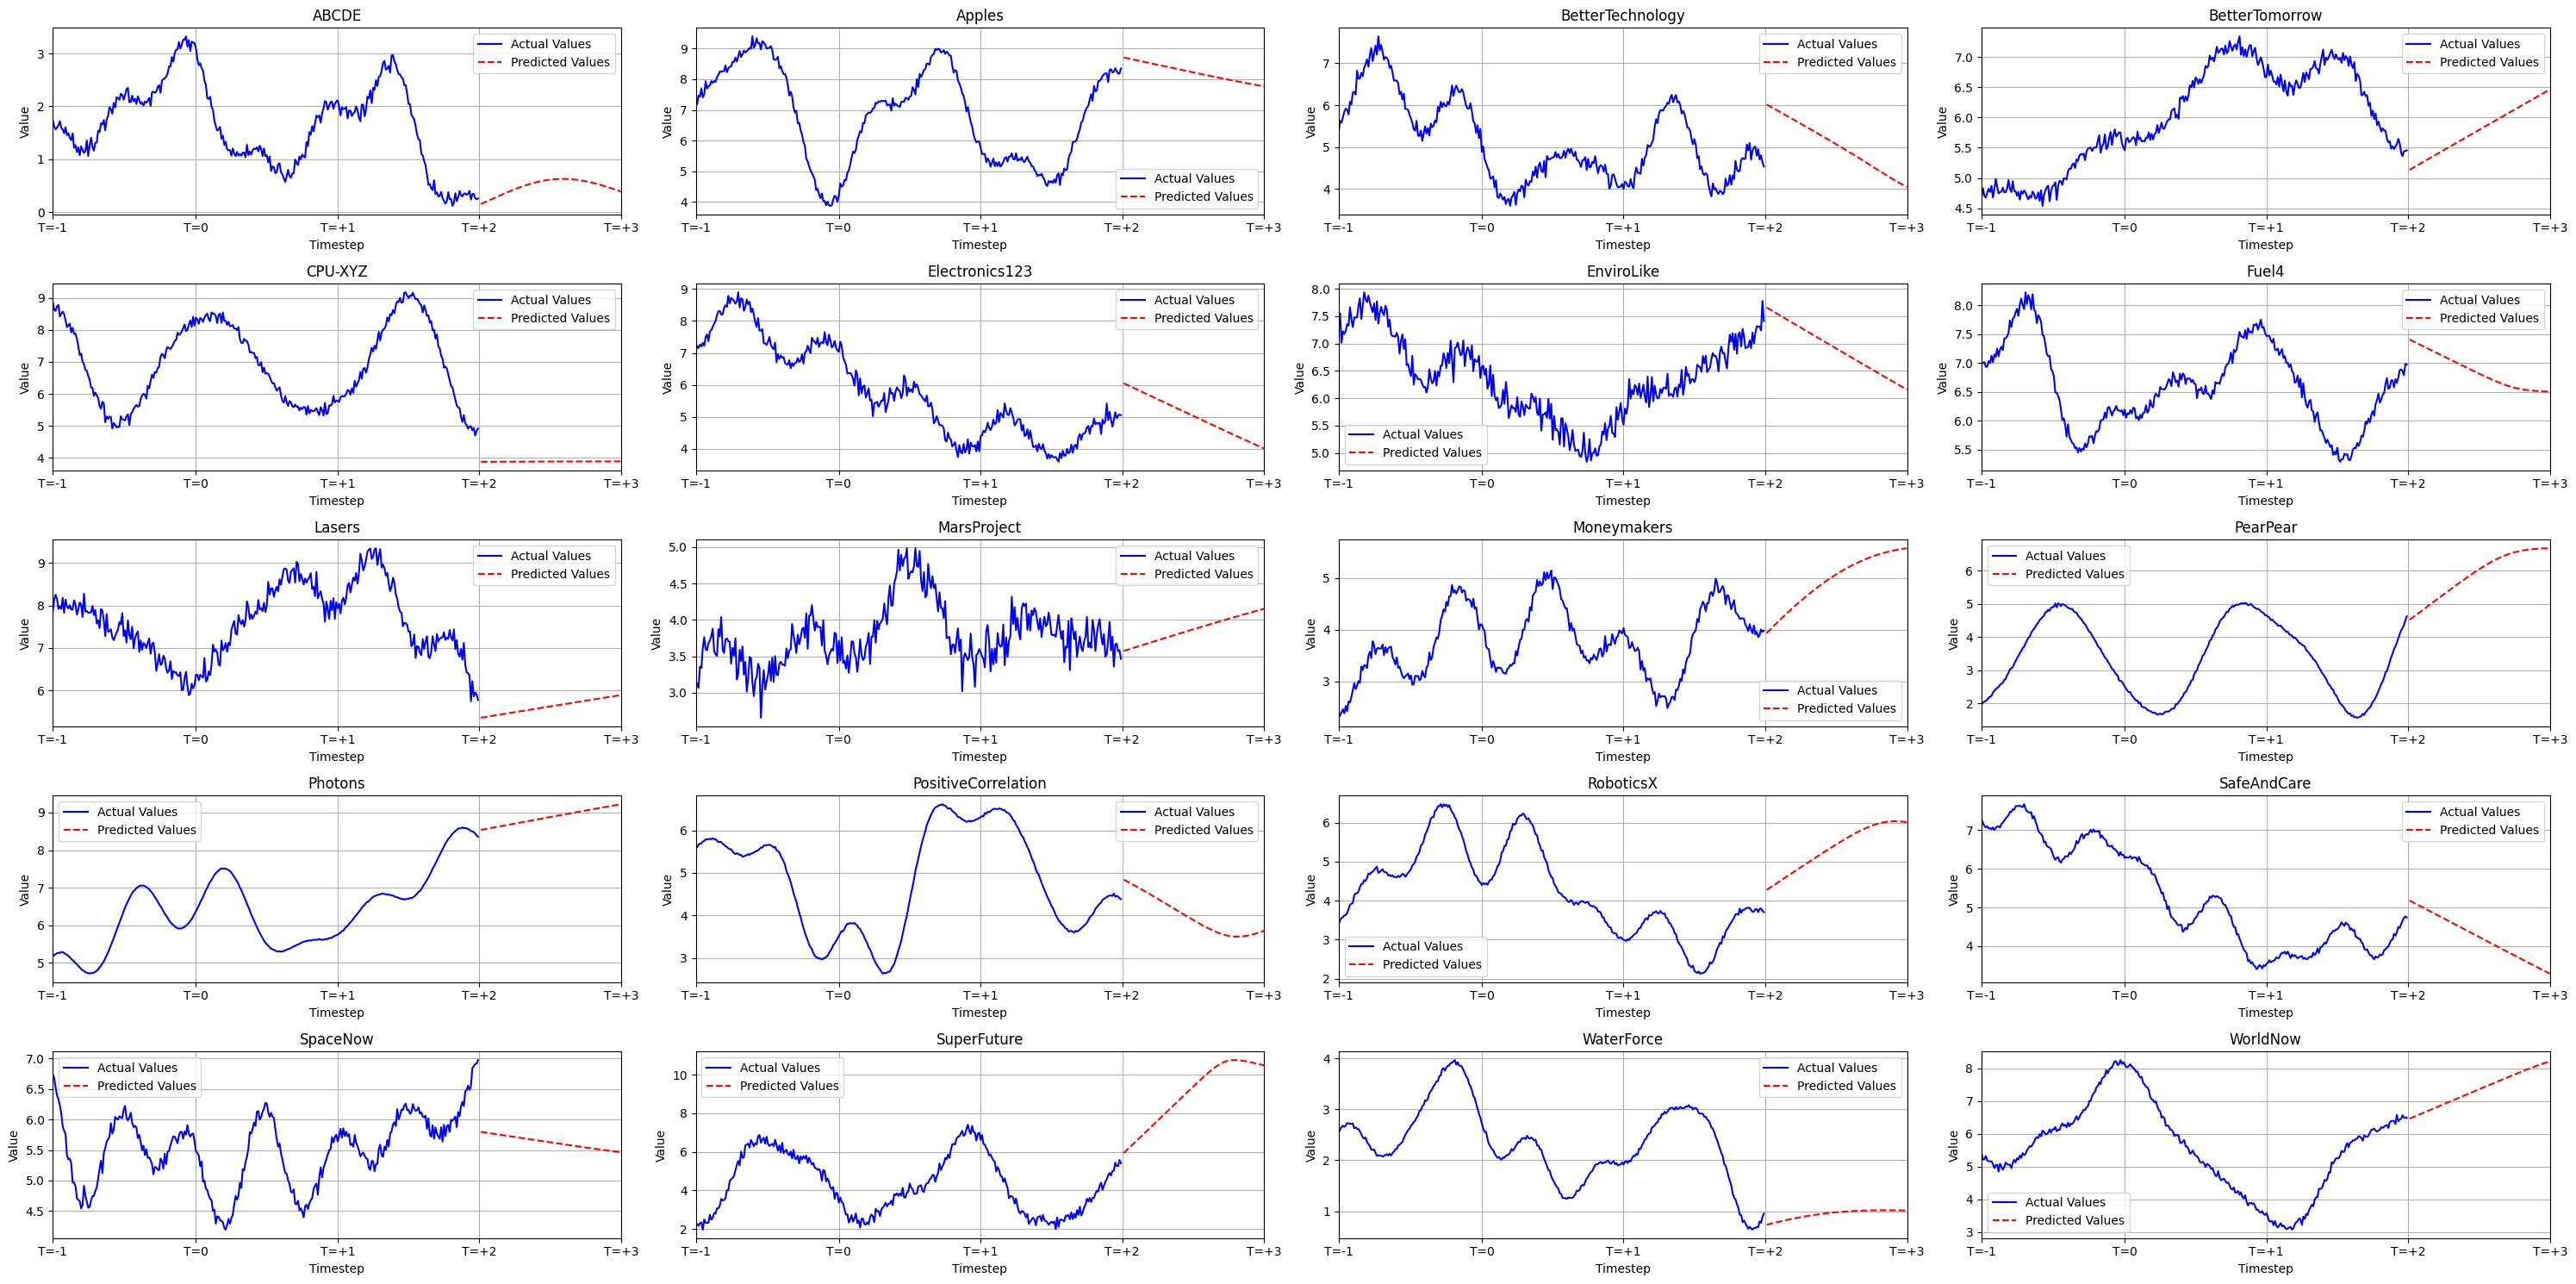

In [10]:
for model in regression_models:
    print(model)
    RMC.plot_predictions(predictions = loaded_data[model], val_range=401, figsize=(30, 15))

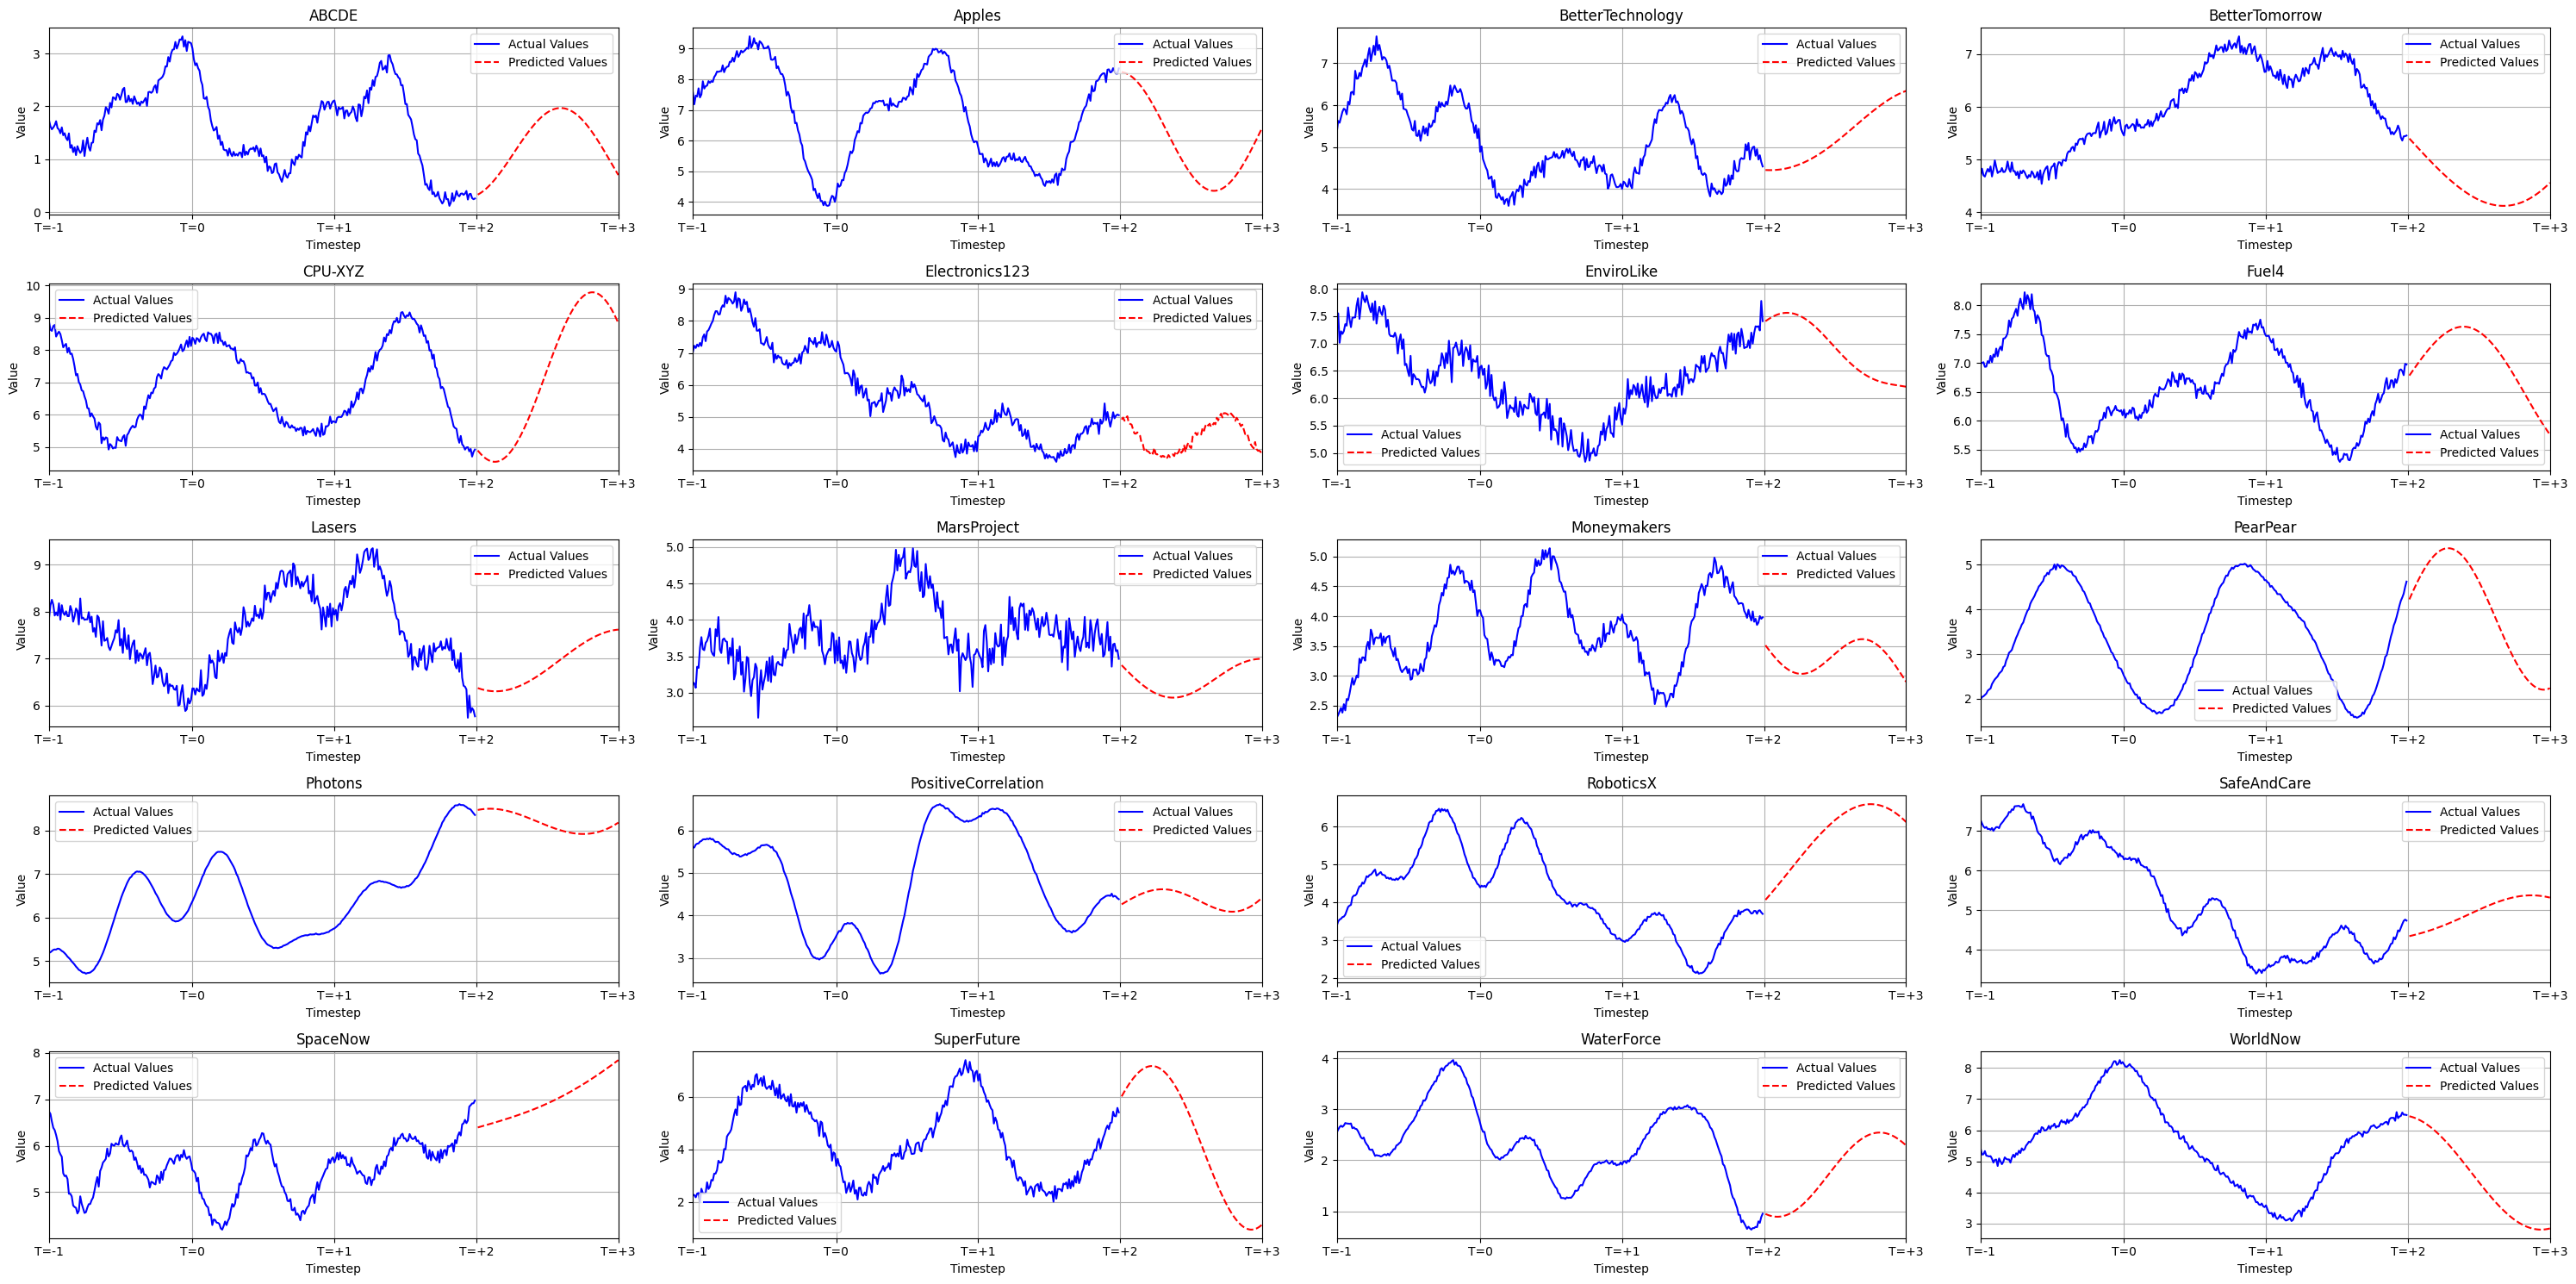

In [37]:
custom_predictions = loaded_data["Sinusoidal"].copy()
# custom_predictions["BetterTechnology"] = loaded_data["Linear"]["BetterTechnology"]
# custom_predictions["BetterTomorrow"] = loaded_data["ARIMA"]["BetterTomorrow"]
# custom_predictions["Electronics123"] = loaded_data["XGBoost"]["Electronics123"]

# custom_predictions["RoboticsX"] = loaded_data["Linear"]["RoboticsX"]
# custom_predictions["WaterForce"] = loaded_data["NODE"]["WaterForce"]
# custom_predictions["WorldNow"] = loaded_data["Linear"]["WorldNow"]

custom_predictions["Electronics123"] = loaded_data["XGBoost"]["Electronics123"]
custom_predictions["SafeAndCare"] = loaded_data["Complex Sinusoidal"]["SafeAndCare"]

RMC.plot_predictions(predictions = custom_predictions, val_range=401, figsize=(30, 15))

In [38]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, custom_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  5.2543e-03 -2.1654e+01  2e+01  2e-16  9e-16
 1:  4.1977e-03 -6.0591e-01  6e-01  2e-16  1e-15
 2:  1.3360e-03 -1.5948e-02  2e-02  2e-16  2e-16
 3:  7.2545e-04 -1.2412e-03  2e-03  2e-16  2e-16
 4:  5.3621e-04  2.7022e-04  3e-04  1e-16  2e-16
 5:  4.9038e-04  4.7712e-04  1e-05  1e-16  1e-16
 6:  4.8514e-04  4.8469e-04  5e-07  2e-16  1e-16
 7:  4.8490e-04  4.8489e-04  5e-09  2e-16  1e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.8281e+00 -3.0132e+01  1e+02  2e+00  4e-16
 1: -1.4692e+00 -1.3027e+01  1e+01  8e-02  6e-16
 2: -1.2557e+00 -2.7348e+00  2e+00  7e-03  1e-15
 3: -1.6198e+00 -1.8290e+00  2e-01  1e-04  9e-16
 4: -1.7050e+00 -1.7072e+00  2e-03  1e-06  8e-16
 5: -1.7059e+00 -1.7059e+00  2e-05  1e-08  7e-16
 6: -1.7059e+00 -1.7059e+00  2e-07  1e-10  7e-16
Optimal solution found.


Running for w1=0.0, w2=1.0
     pcost       dcost       gap    pres   dres
 0: -9.4082e+00 -3.5458e+01  2e+02  2e+00  4e-16
 1: -3.5329e+00 -1.7397e+01  2e+01  1e-01  7e-16
 2: -2.3984e+00 -4.0524e+00  2e+00  1e-02  2e-15
 3: -2.6552e+00 -2.7827e+00  1e-01  4e-04  6e-16
 4: -2.6895e+00 -2.6908e+00  1e-03  4e-06  5e-16
 5: -2.6899e+00 -2.6899e+00  1e-05  4e-08  6e-16
 6: -2.6899e+00 -2.6899e+00  1e-07  4e-10  4e-16
Optimal solution found.
Running for w1=0.1, w2=0.9
     pcost       dcost       gap    pres   dres
 0: -6.5181e+00 -3.1953e+01  1e+02  2e+00  5e-16
 1: -2.8110e+00 -1.4755e+01  2e+01  1e-01  8e-16
 2: -2.0329e+00 -3.1870e+00  1e+00  7e-03  1e-15
 3: -2.3392e+00 -2.4718e+00  1e-01  4e-04  9e-16
 4: -2.3805e+00 -2.3818e+00  1e-03  4e-06  6e-16
 5: -2.3809e+00 -2.3809e+00  1e-05  4e-08  7e-16
 6: -2.3809e+00 -2.3809e+00  1e-07  4e-10  5e-16
Optimal solution found.
Running for w1=0.2, w2=0.8
     pcost       dcost       gap    pres   dres
 0: -4.6377e+00 -3.0014e+01  1e+02  2e+00

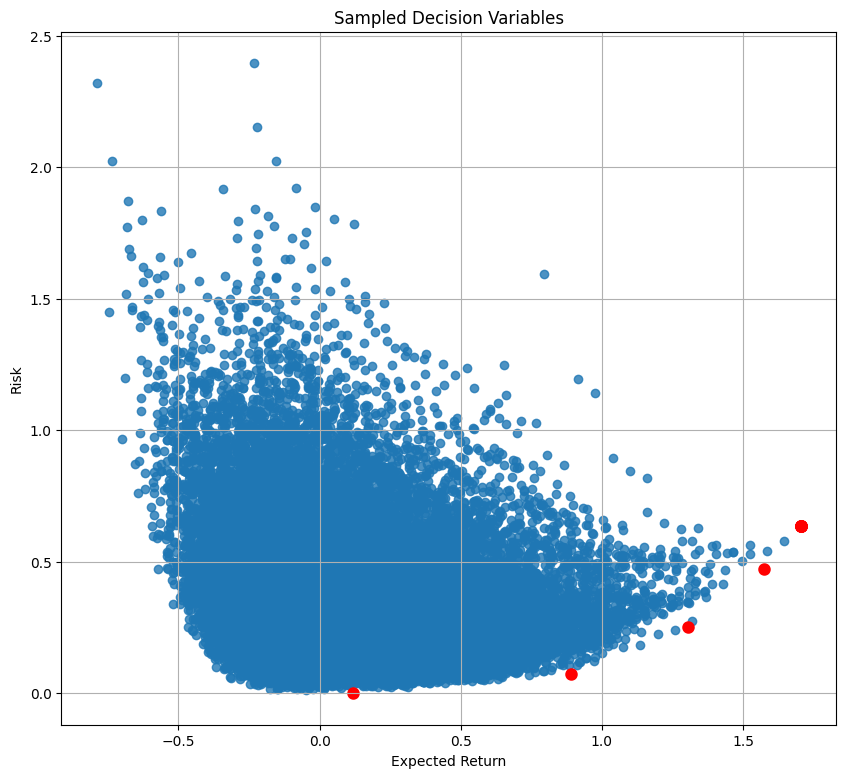

In [39]:
solutions = solver.solve_wsm()
solver.plot_front(solutions, n=20, step=0.2)

Running for threshold=0.11735910938074948
     pcost       dcost       gap    pres   dres
 0:  5.2483e-03 -2.1654e+01  2e+01  2e-15  6e+00
 1:  4.2117e-03 -5.9646e-01  6e-01  2e-16  2e-01
 2:  1.5809e-03 -1.5972e-02  2e-02  1e-16  2e-03
 3:  7.2899e-04 -1.2968e-03  2e-03  2e-16  1e-04
 4:  5.3431e-04  2.4470e-04  3e-04  2e-16  1e-16
 5:  4.9112e-04  4.5982e-04  3e-05  1e-16  2e-16
 6:  4.8526e-04  4.8431e-04  1e-06  1e-16  1e-16
 7:  4.8491e-04  4.8488e-04  3e-08  2e-16  1e-16
Optimal solution found.
Running for threshold=0.14977767823832644
     pcost       dcost       gap    pres   dres
 0:  5.4768e-03 -2.1669e+01  8e+01  1e+00  6e+00
 1:  6.0635e-02 -7.5918e+00  9e+00  4e-02  1e-01
 2:  3.4601e-02 -3.3977e-01  4e-01  7e-04  3e-03
 3:  1.0319e-02 -5.7980e-02  7e-02  8e-05  3e-04
 4:  2.4399e-03 -1.3172e-02  2e-02  5e-06  2e-05
 5:  8.2728e-04 -8.7696e-04  2e-03  3e-16  2e-16
 6:  5.7187e-04  3.0856e-04  3e-04  2e-16  2e-16
 7:  5.2364e-04  4.6672e-04  6e-05  2e-16  2e-16
 8:  5.0546e

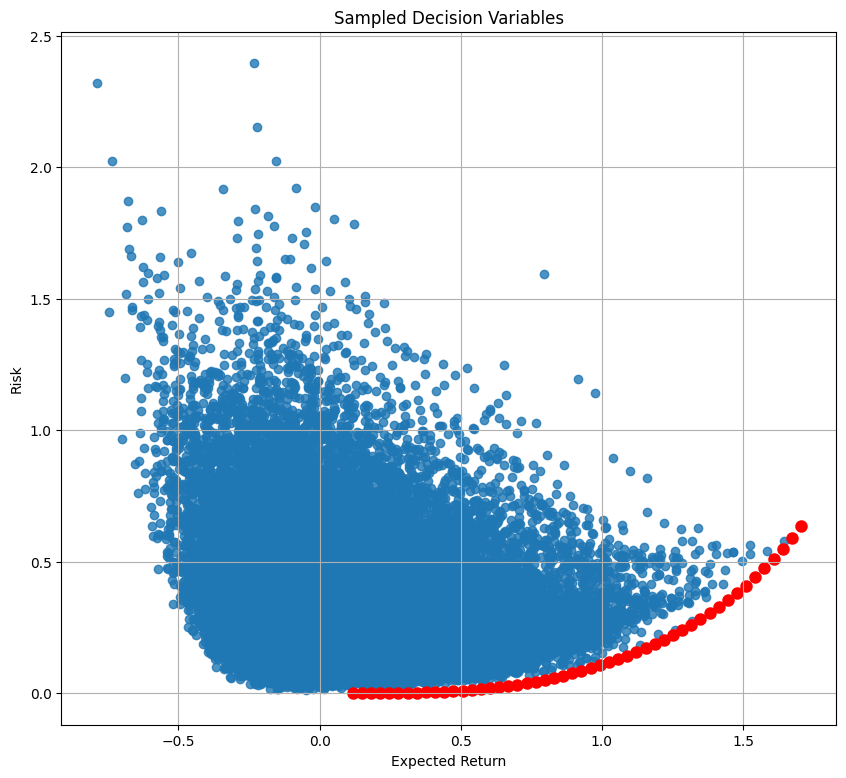

In [40]:
solutions = solver.solve_ecm(50)
solver.plot_front(solutions, n=20, step=0.2)

In [41]:
df = pretty_display(solutions)
df

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,0.118002,0.000485,4.001316e-03,3.471566e-02,2.141843e-02,1.884415e-02,1.414979e-01,5.103206e-02,6.930555e-07,1.076225e-01,...,1.201620e-01,1.349987e-01,9.950252e-06,9.022156e-02,2.806105e-02,1.556737e-02,3.193605e-02,4.814326e-02,1.109643e-01,1.0
1,0.149781,0.000504,9.308487e-07,4.026622e-02,1.527461e-02,9.291447e-03,1.429848e-01,4.636024e-02,3.032201e-07,1.093664e-01,...,1.365123e-01,1.336239e-01,5.686861e-06,9.092098e-02,2.856447e-02,1.499224e-02,2.563889e-02,5.098291e-02,9.436797e-02,1.0
2,0.182197,0.000580,4.943925e-08,4.741216e-02,5.711958e-03,2.625993e-04,1.459778e-01,4.055141e-02,5.824042e-08,1.089013e-01,...,1.542681e-01,1.282630e-01,1.177538e-05,9.698462e-02,2.836520e-02,1.578249e-02,1.290437e-02,5.463283e-02,7.524614e-02,1.0
3,0.214615,0.000728,1.513522e-08,5.824045e-02,2.337122e-08,9.877014e-08,1.464522e-01,3.197113e-02,2.141316e-08,1.108153e-01,...,1.697742e-01,1.205388e-01,9.774664e-06,1.052626e-01,2.653405e-02,1.225741e-02,6.174457e-03,4.529821e-02,5.893910e-02,1.0
4,0.247033,0.000982,1.711620e-08,6.965957e-02,1.610257e-08,6.027253e-08,1.439089e-01,2.266956e-02,3.012948e-08,1.154978e-01,...,1.847975e-01,1.131317e-01,1.132304e-04,1.141791e-01,2.433683e-02,1.015125e-02,3.673297e-03,2.976923e-02,3.921137e-02,1.0
5,0.279452,0.001346,1.514045e-09,8.107580e-02,4.174599e-09,3.423511e-09,1.413740e-01,1.333080e-02,2.008251e-09,1.201797e-01,...,1.997913e-01,1.057410e-01,3.769410e-04,1.230776e-01,2.210348e-02,8.004280e-03,1.186975e-03,1.423509e-02,1.944149e-02,1.0
6,0.311871,0.001819,8.503096e-10,9.224688e-02,2.044636e-09,1.705052e-09,1.395110e-01,3.339790e-03,1.161148e-09,1.230776e-01,...,2.133861e-01,9.901007e-02,2.647646e-03,1.303899e-01,1.822124e-02,6.665893e-03,4.095767e-05,2.383522e-08,2.457820e-04,1.0
7,0.344289,0.002479,1.154098e-08,1.020453e-01,1.804713e-08,3.256746e-08,1.396327e-01,3.353702e-06,1.956982e-08,1.068020e-01,...,2.107336e-01,9.432155e-02,3.680567e-06,1.259270e-01,7.825374e-03,1.733884e-02,1.750941e-03,2.438810e-07,1.226959e-07,1.0
8,0.376708,0.003408,8.026912e-11,1.106190e-01,1.131299e-10,2.008833e-10,1.385919e-01,5.721208e-10,1.285517e-10,9.097092e-02,...,2.047716e-01,8.888311e-02,6.812005e-09,1.212467e-01,2.204238e-07,2.739153e-02,2.474769e-03,1.050102e-09,5.126667e-10,1.0
9,0.409126,0.004674,5.513978e-11,1.162137e-01,5.759034e-11,8.562160e-11,1.369593e-01,2.061255e-09,7.619755e-11,8.025242e-02,...,1.975093e-01,7.984941e-02,7.578277e-10,1.177849e-01,1.598492e-09,3.676139e-02,1.674497e-06,2.237178e-10,4.011329e-10,1.0


In [53]:
id = 10
print(df.iloc[id].Risk)
# Print columns in sorted by value order
res = []
for c in df.columns:
    res.append([c, df.iloc[id][c]])

for c, r in sorted(res, key=lambda x: x[1], reverse=True):
    print(c, r)

0.006314313742977582
Sanity Check 1.0000000000000002
Expected Gain 0.44154480262156337
ABCDE 0.25244442434657133
Moneymakers 0.1897905963252828
Photons 0.13546797359010387
Apples 0.12140917024605939
CPU-XYZ 0.11377578319768022
Fuel4 0.07150413547601973
PositiveCorrelation 0.06946533374143525
Lasers 0.04613845213274738
Risk 0.006314313742977582
WaterForce 3.639267480165184e-06
SpaceNow 3.7907847437989703e-07
MarsProject 3.044876392030182e-08
EnviroLike 3.042258928441218e-08
RoboticsX 2.054374420458902e-08
BetterTomorrow 1.0713680824089184e-08
BetterTechnology 7.185072901340189e-09
SafeAndCare 5.230135525733248e-09
PearPear 2.3960327600276757e-09
Electronics123 2.3595820444877276e-09
SuperFuture 1.7095227920653057e-09
WorldNow 1.589021274164272e-09


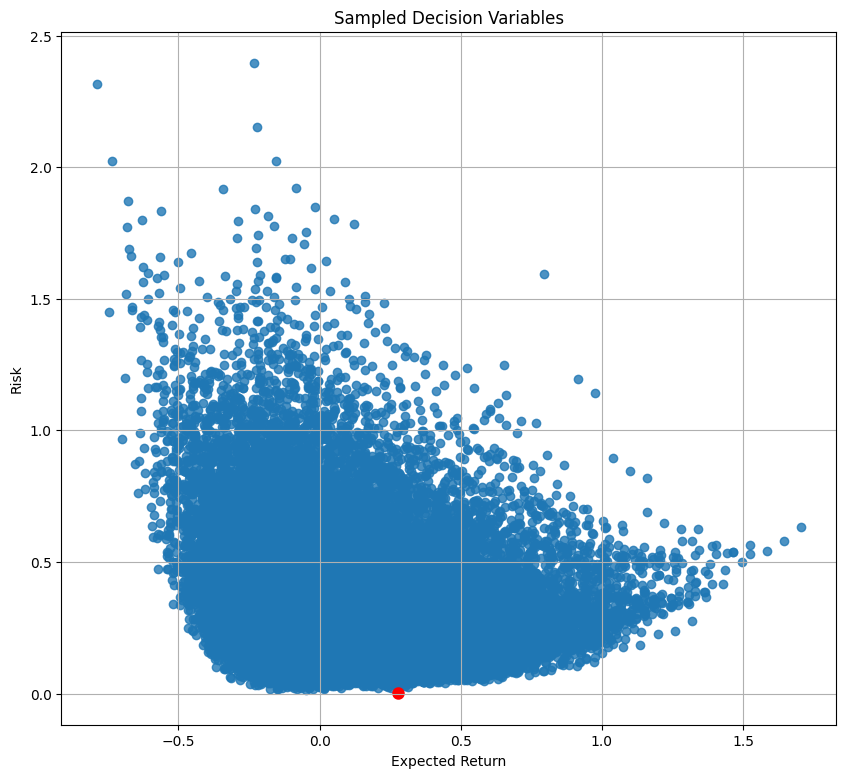

In [43]:
solver.plot_front([solutions[id]])

In [44]:
def save_solution(df, index, value, filename="151945_151942.txt"):
    row = df.iloc[index]
    expected_total_return = (1.0 + row["Expected Gain"]) * value
    expected_total_risk = row["Risk"]
    weights = [row[company] for company in ORDER]
    solution_line = f"{expected_total_return:.10f} {(100*expected_total_risk):.10f} " + " ".join(f"{w:.10f}" for w in weights)
    with open(filename, "w") as file:
        file.write(solution_line)
    print(f"Solution saved successfully in {filename} with a produced weight sum: {sum(weights)}")



In [45]:
save_solution(df, id, 100)

Solution saved successfully in 151945_151942.txt with a produced weight sum: 0.9999999999999999
